In [42]:
import pandas as pd

bissell = pd.read_csv("Bissell_Thrift_118_Ave_01012025-01012026(Production 2025) (1).csv")
visser = pd.read_csv("Visser_plant_report(in).csv")

print("Bissell shape:", bissell.shape)
print("Visser shape:", visser.shape)

print("\nBissell columns:")
print(bissell.columns.tolist())

print("\nVisser columns:")
print(visser.columns.tolist())

print("\nBissell head:")
print(bissell.head())

print("\nVisser head:")
print(visser.head())


Bissell shape: (137, 9)
Visser shape: (12, 48)

Bissell columns:
['Date and time', 'Energy per inverter | Primo 7.6-1 208-240 (1)', 'Energy per inverter | Primo 7.6-1 208-240 (2)', 'Energy per inverter | Primo 7.6-1 208-240 (3)', 'Energy per inverter per kWp | Primo 7.6-1 208-240 (1)', 'Energy per inverter per kWp | Primo 7.6-1 208-240 (2)', 'Energy per inverter per kWp | Primo 7.6-1 208-240 (3)', 'Total system', 'Unnamed: 8']

Visser columns:
['Date', 'Plant Name', 'Plant ID', 'Current Status', 'Country', 'Region', 'City', 'County', 'Plant Address', 'Owner', 'Owner Contact Information', 'Inverter Number', 'Installed Capacity (kWp)', 'This Month Full Load Hours (h)', 'Monthly Yield (kWh)', 'This Month Earning', 'Total Yield (kWh)', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31']

Bissell head:
  Date and time Energy per inverter | Primo 7.6-1 208-240 (1)  \
0

In [43]:
import pandas as pd
import numpy as np

# Reload with your filenames
bissell = pd.read_csv("Bissell_Thrift_118_Ave_01012025-01012026(Production 2025) (1).csv")
visser = pd.read_csv("Visser_plant_report(in).csv")

# Remove fully empty columns
bissell = bissell.dropna(axis=1, how='all')

# Keep only the real header row data, remove unit row if present
bissell = bissell[bissell.iloc[:, 0] != '[dd.MM.yyyy]'].copy()

# Rename columns for easier use
bissell.columns = [
    'date',
    'inv1_kwh',
    'inv2_kwh',
    'inv3_kwh',
    'inv1_kwh_per_kwp',
    'inv2_kwh_per_kwp',
    'inv3_kwh_per_kwp',
    'total_system_kwh'
]

# Strip spaces and convert types
for col in bissell.columns:
    bissell[col] = bissell[col].astype(str).str.strip()

bissell['date'] = pd.to_datetime(bissell['date'], format='%d.%m.%Y', errors='coerce')

num_cols = [col for col in bissell.columns if col != 'date']
for col in num_cols:
    bissell[col] = pd.to_numeric(bissell[col], errors='coerce')

# Remove bad rows
bissell = bissell.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

print("Cleaned Bissell shape:", bissell.shape)
print("\nMissing values:")
print(bissell.isna().sum())

print("\nData types:")
print(bissell.dtypes)

print("\nCleaned Bissell head:")
print(bissell.head())

print("\nCleaned Bissell tail:")
print(bissell.tail())


Cleaned Bissell shape: (135, 8)

Missing values:
date                0
inv1_kwh            0
inv2_kwh            0
inv3_kwh            0
inv1_kwh_per_kwp    0
inv2_kwh_per_kwp    0
inv3_kwh_per_kwp    0
total_system_kwh    0
dtype: int64

Data types:
date                datetime64[ns]
inv1_kwh                   float64
inv2_kwh                   float64
inv3_kwh                   float64
inv1_kwh_per_kwp           float64
inv2_kwh_per_kwp           float64
inv3_kwh_per_kwp           float64
total_system_kwh           float64
dtype: object

Cleaned Bissell head:
        date  inv1_kwh  inv2_kwh  inv3_kwh  inv1_kwh_per_kwp  \
0 2025-08-20  44.39249  41.39772  37.03470           3.97782   
1 2025-08-21  42.50207  39.09753  35.77678           3.80843   
2 2025-08-22  50.78082  46.68729  42.92988           4.55025   
3 2025-08-23  56.00988  51.02283  45.75087           5.01881   
4 2025-08-24  56.03522  50.94575  46.17663           5.02108   

   inv2_kwh_per_kwp  inv3_kwh_per_kwp  total_sy

In [44]:
import pandas as pd
import numpy as np

# Reload Visser
visser = pd.read_csv("Visser_plant_report(in).csv")

# Standardize Plant ID
visser['Plant ID'] = visser['Plant ID'].astype(str).str.replace("'", "", regex=False).str.strip()

# Convert monthly date column
visser['Date'] = pd.to_datetime(visser['Date'], format='%y-%b', errors='coerce')

# Daily columns are 1 to 31
day_cols = [str(i) for i in range(1, 32)]

# Convert daily columns to numeric
for col in day_cols:
    visser[col] = pd.to_numeric(visser[col], errors='coerce')

# Reshape from wide to long
visser_long = visser.melt(
    id_vars=['Date', 'Plant Name', 'Plant ID', 'Current Status', 'Country', 'Region',
             'City', 'County', 'Plant Address', 'Owner', 'Owner Contact Information',
             'Inverter Number', 'Installed Capacity (kWp)', 'This Month Full Load Hours (h)',
             'Monthly Yield (kWh)', 'This Month Earning', 'Total Yield (kWh)'],
    value_vars=day_cols,
    var_name='day',
    value_name='daily_output_kwh'
)

# Build actual daily date
visser_long['day'] = pd.to_numeric(visser_long['day'], errors='coerce')
visser_long['daily_date'] = pd.to_datetime(
    visser_long['Date'].dt.strftime('%Y-%m-') + visser_long['day'].astype('Int64').astype(str),
    errors='coerce'
)

# Drop invalid calendar dates and rows with no daily value
visser_long = visser_long.dropna(subset=['daily_date', 'daily_output_kwh']).copy()

# Sort
visser_long = visser_long.sort_values('daily_date').reset_index(drop=True)

print("Original Visser shape:", visser.shape)
print("Reshaped Visser shape:", visser_long.shape)

print("\nMissing values in reshaped Visser:")
print(visser_long.isna().sum())

print("\nUnique Plant IDs:")
print(visser_long['Plant ID'].unique())

print("\nCurrent Status values:")
print(visser_long['Current Status'].unique())

print("\nReshaped Visser head:")
print(visser_long[['daily_date', 'Plant Name', 'Plant ID', 'daily_output_kwh']].head())

print("\nReshaped Visser tail:")
print(visser_long[['daily_date', 'Plant Name', 'Plant ID', 'daily_output_kwh']].tail())


Original Visser shape: (12, 48)
Reshaped Visser shape: (304, 20)

Missing values in reshaped Visser:
Date                                0
Plant Name                          0
Plant ID                            0
Current Status                      0
Country                             0
Region                              0
City                                0
County                              0
Plant Address                       0
Owner                             304
Owner Contact Information           0
Inverter Number                     0
Installed Capacity (kWp)            0
This Month Full Load Hours (h)      0
Monthly Yield (kWh)                 0
This Month Earning                  0
Total Yield (kWh)                   0
day                                 0
daily_output_kwh                    0
daily_date                          0
dtype: int64

Unique Plant IDs:
['2318D5']

Current Status values:
['Offline']

Reshaped Visser head:
  daily_date   Plant Name Plant ID  d

Bissell summary statistics:
                      date    inv1_kwh    inv2_kwh    inv3_kwh  \
count                  135  135.000000  135.000000  135.000000   
mean   2025-10-26 00:00:00   16.714645   15.314808   14.160444   
min    2025-08-20 00:00:00    0.000000    0.000000    0.000000   
25%    2025-09-22 12:00:00    0.128020    0.113460    0.095160   
50%    2025-10-26 00:00:00   11.279240   10.636850    9.631380   
75%    2025-11-28 12:00:00   27.684865   24.836505   23.873530   
max    2026-01-01 00:00:00   56.035220   51.022830   46.176630   
std                    NaN   16.634778   15.099935   13.847359   

       inv1_kwh_per_kwp  inv2_kwh_per_kwp  inv3_kwh_per_kwp  total_system_kwh  
count        135.000000        135.000000        135.000000        135.000000  
mean           1.497728          1.497048          1.522629         46.189896  
min            0.000000          0.000000          0.000000          0.000000  
25%            0.011475          0.011090          0.0102

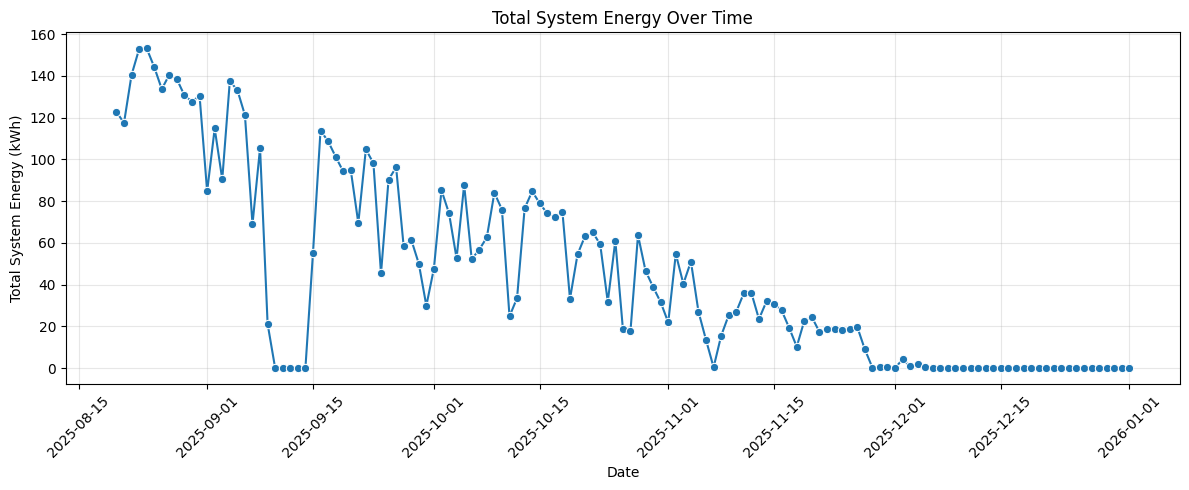

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature summary for Bissell
print("Bissell summary statistics:")
print(bissell.describe())

print("\nDate range:")
print("Start:", bissell['date'].min())
print("End:", bissell['date'].max())

# Plot 1: total system production over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=bissell, x='date', y='total_system_kwh', marker='o')
plt.title('Total System Energy Over Time')
plt.xlabel('Date')
plt.ylabel('Total System Energy (kWh)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


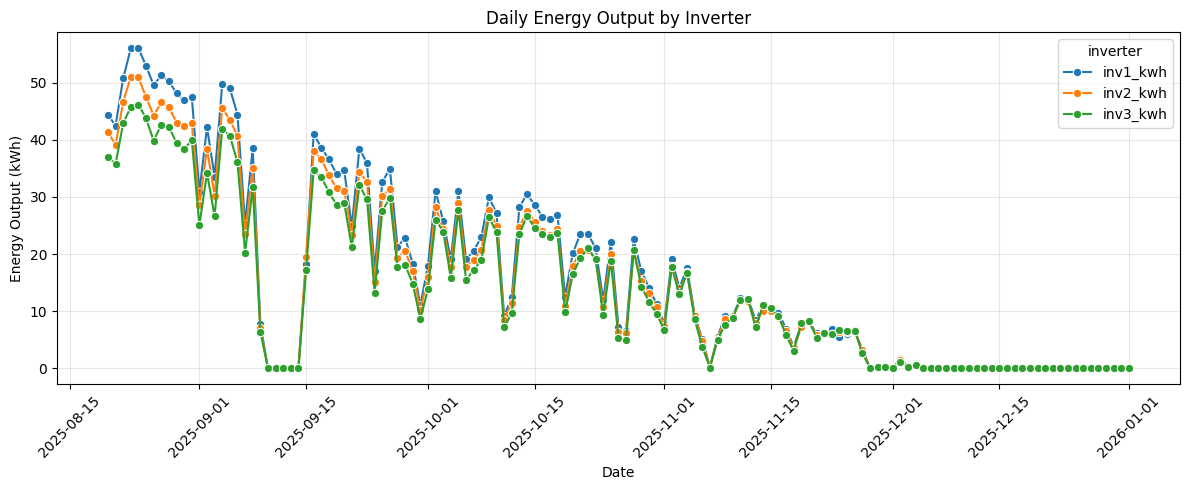

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to long format for inverter comparison
bissell_long = bissell.melt(
    id_vars='date',
    value_vars=['inv1_kwh', 'inv2_kwh', 'inv3_kwh'],
    var_name='inverter',
    value_name='energy_kwh'
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=bissell_long, x='date', y='energy_kwh', hue='inverter', marker='o')
plt.title('Daily Energy Output by Inverter')
plt.xlabel('Date')
plt.ylabel('Energy Output (kWh)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


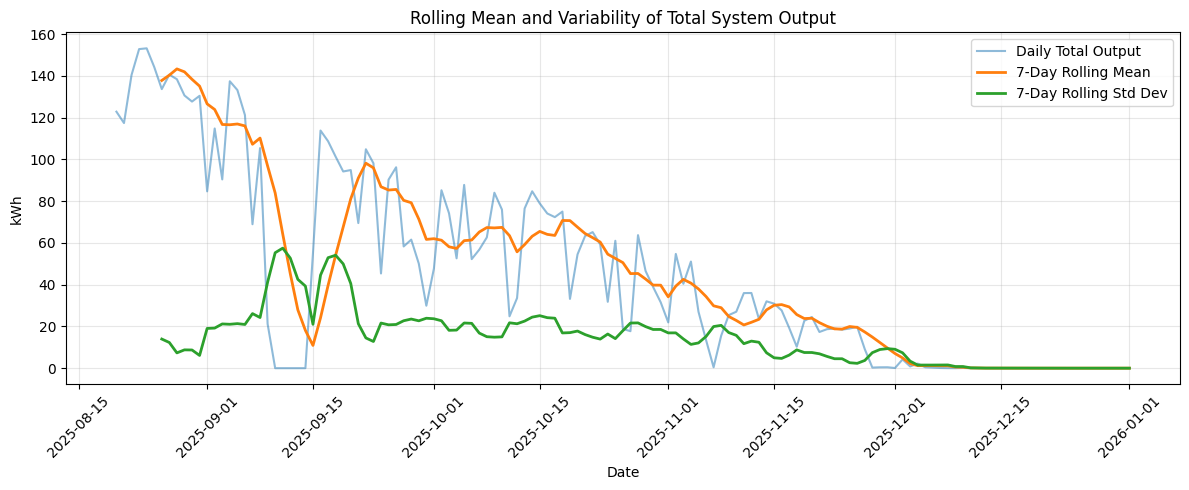

In [47]:
import matplotlib.pyplot as plt

# Rolling statistics for total system output
bissell['rolling_mean_7'] = bissell['total_system_kwh'].rolling(window=7).mean()
bissell['rolling_std_7'] = bissell['total_system_kwh'].rolling(window=7).std()

plt.figure(figsize=(12, 5))
plt.plot(bissell['date'], bissell['total_system_kwh'], label='Daily Total Output', alpha=0.5)
plt.plot(bissell['date'], bissell['rolling_mean_7'], label='7-Day Rolling Mean', linewidth=2)
plt.plot(bissell['date'], bissell['rolling_std_7'], label='7-Day Rolling Std Dev', linewidth=2)
plt.title('Rolling Mean and Variability of Total System Output')
plt.xlabel('Date')
plt.ylabel('kWh')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Number of flagged anomalies: 7

Flagged anomaly dates:
         date  total_system_kwh  z_score_total
2  2025-08-22         140.39799       2.067534
3  2025-08-23         152.78358       2.339354
4  2025-08-24         153.15760       2.347562
5  2025-08-25         144.22354       2.151491
7  2025-08-27         140.55812       2.071048
8  2025-08-28         138.35819       2.022768
15 2025-09-04         137.38585       2.001428


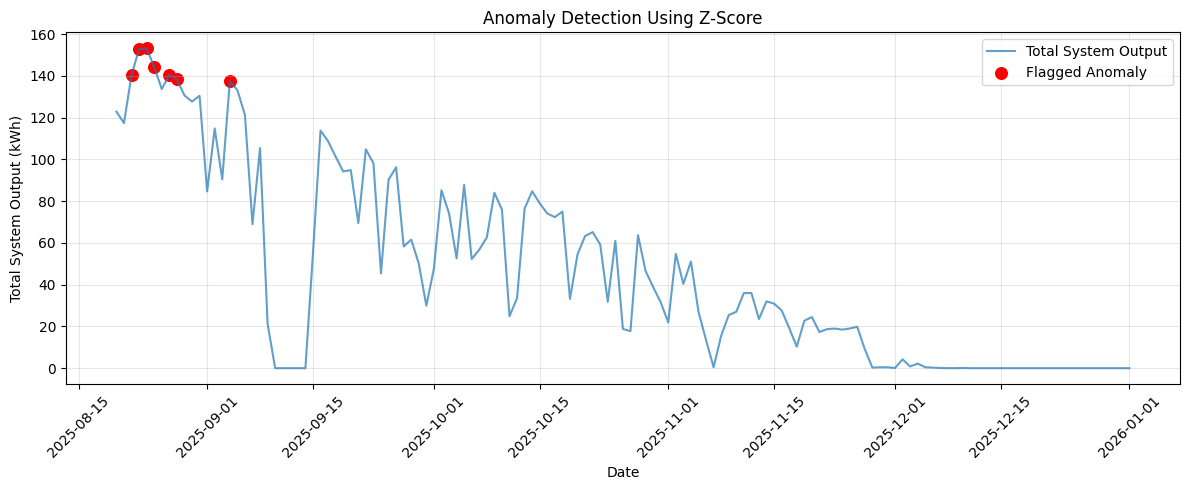

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Z-score for total system output
bissell['z_score_total'] = (
    (bissell['total_system_kwh'] - bissell['total_system_kwh'].mean()) /
    bissell['total_system_kwh'].std()
)

# Flag anomalies using threshold
bissell['anomaly_flag'] = np.where(bissell['z_score_total'].abs() > 2, 1, 0)

print("Number of flagged anomalies:", bissell['anomaly_flag'].sum())
print("\nFlagged anomaly dates:")
print(bissell.loc[bissell['anomaly_flag'] == 1, ['date', 'total_system_kwh', 'z_score_total']])

# Plot anomalies
plt.figure(figsize=(12, 5))
plt.plot(bissell['date'], bissell['total_system_kwh'], label='Total System Output', alpha=0.7)
plt.scatter(
    bissell.loc[bissell['anomaly_flag'] == 1, 'date'],
    bissell.loc[bissell['anomaly_flag'] == 1, 'total_system_kwh'],
    color='red',
    label='Flagged Anomaly',
    s=70
)
plt.title('Anomaly Detection Using Z-Score')
plt.xlabel('Date')
plt.ylabel('Total System Output (kWh)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


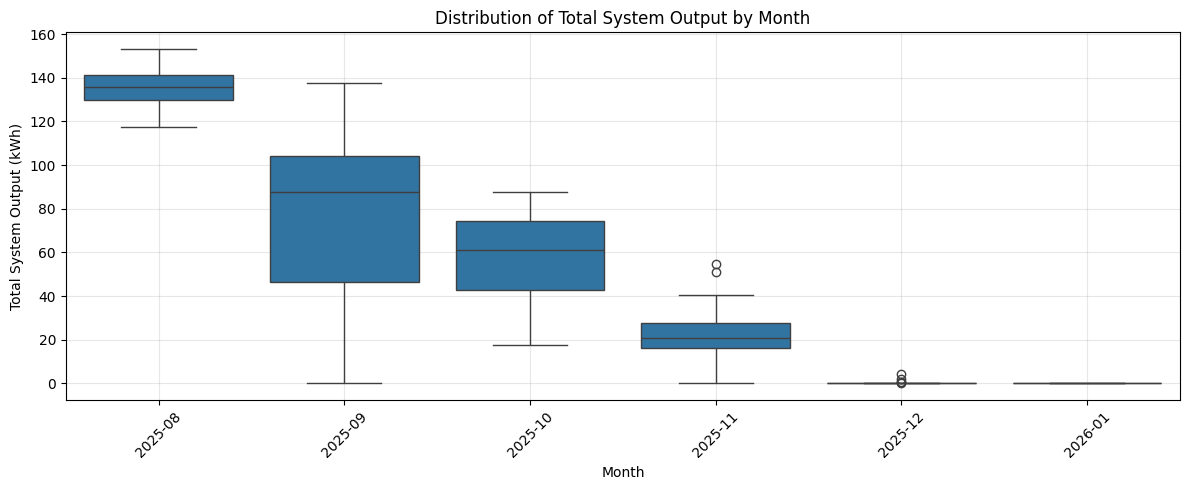

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create month label
bissell['month'] = bissell['date'].dt.strftime('%Y-%m')

plt.figure(figsize=(12, 5))
sns.boxplot(data=bissell, x='month', y='total_system_kwh')
plt.title('Distribution of Total System Output by Month')
plt.xlabel('Month')
plt.ylabel('Total System Output (kWh)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


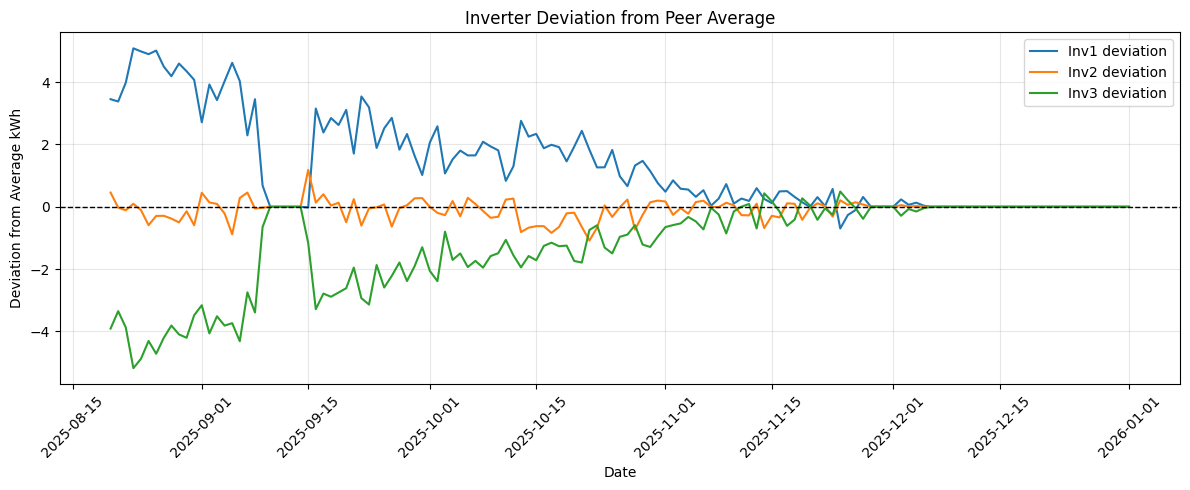

In [50]:
import matplotlib.pyplot as plt

# Peer deviation: inverter output minus average of all three
bissell['avg_inverter_kwh'] = bissell[['inv1_kwh', 'inv2_kwh', 'inv3_kwh']].mean(axis=1)
bissell['inv1_dev'] = bissell['inv1_kwh'] - bissell['avg_inverter_kwh']
bissell['inv2_dev'] = bissell['inv2_kwh'] - bissell['avg_inverter_kwh']
bissell['inv3_dev'] = bissell['inv3_kwh'] - bissell['avg_inverter_kwh']

plt.figure(figsize=(12, 5))
plt.plot(bissell['date'], bissell['inv1_dev'], label='Inv1 deviation')
plt.plot(bissell['date'], bissell['inv2_dev'], label='Inv2 deviation')
plt.plot(bissell['date'], bissell['inv3_dev'], label='Inv3 deviation')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Inverter Deviation from Peer Average')
plt.xlabel('Date')
plt.ylabel('Deviation from Average kWh')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [51]:
# Top low-output days
lowest_days = bissell[['date', 'total_system_kwh', 'inv1_kwh', 'inv2_kwh', 'inv3_kwh']].sort_values(
    'total_system_kwh'
).head(10)

# Average deviation by inverter
avg_dev = pd.DataFrame({
    'inverter': ['inv1', 'inv2', 'inv3'],
    'average_deviation_from_peer': [
        bissell['inv1_dev'].mean(),
        bissell['inv2_dev'].mean(),
        bissell['inv3_dev'].mean()
    ]
})

# Monthly average total output
monthly_summary = bissell.groupby('month')['total_system_kwh'].agg(['mean', 'median', 'min', 'max']).reset_index()

print("Top 10 lowest-output days:")
print(lowest_days)

print("\nAverage inverter deviation from peer average:")
print(avg_dev)

print("\nMonthly total system summary:")
print(monthly_summary)


Top 10 lowest-output days:
          date  total_system_kwh  inv1_kwh  inv2_kwh  inv3_kwh
24  2025-09-13               0.0       0.0       0.0       0.0
21  2025-09-10               0.0       0.0       0.0       0.0
23  2025-09-12               0.0       0.0       0.0       0.0
25  2025-09-14               0.0       0.0       0.0       0.0
22  2025-09-11               0.0       0.0       0.0       0.0
121 2025-12-19               0.0       0.0       0.0       0.0
122 2025-12-20               0.0       0.0       0.0       0.0
127 2025-12-25               0.0       0.0       0.0       0.0
116 2025-12-14               0.0       0.0       0.0       0.0
118 2025-12-16               0.0       0.0       0.0       0.0

Average inverter deviation from peer average:
  inverter  average_deviation_from_peer
0     inv1                     1.318012
1     inv2                    -0.081824
2     inv3                    -1.236188

Monthly total system summary:
     month        mean      median        

In [52]:
next_step_table = pd.DataFrame({
    'component': [
        'Baseline method',
        'Target behavior',
        'Input features',
        'Flagging logic',
        'Business use',
        'Recommended next model'
    ],
    'recommendation': [
        'Z-score and peer deviation monitoring',
        'Detect early underperformance before complete failure',
        'Total output, inverter output, peer deviation, rolling mean, rolling std',
        'Flag when output is abnormally low, peer deviation stays negative, or rolling variability shifts',
        'Early-warning system for maintenance and risk mitigation',
        'Rolling threshold model or unsupervised anomaly detection model such as Isolation Forest'
    ]
})

print(next_step_table)


                component                                     recommendation
0         Baseline method              Z-score and peer deviation monitoring
1         Target behavior  Detect early underperformance before complete ...
2          Input features  Total output, inverter output, peer deviation,...
3          Flagging logic  Flag when output is abnormally low, peer devia...
4            Business use  Early-warning system for maintenance and risk ...
5  Recommended next model  Rolling threshold model or unsupervised anomal...


In [53]:
print("Shape:", bissell.shape)
print("\nColumns:")
print(bissell.columns.tolist())
print("\nHead:")
print(bissell.head())


Shape: (135, 17)

Columns:
['date', 'inv1_kwh', 'inv2_kwh', 'inv3_kwh', 'inv1_kwh_per_kwp', 'inv2_kwh_per_kwp', 'inv3_kwh_per_kwp', 'total_system_kwh', 'rolling_mean_7', 'rolling_std_7', 'z_score_total', 'anomaly_flag', 'month', 'avg_inverter_kwh', 'inv1_dev', 'inv2_dev', 'inv3_dev']

Head:
        date  inv1_kwh  inv2_kwh  inv3_kwh  inv1_kwh_per_kwp  \
0 2025-08-20  44.39249  41.39772  37.03470           3.97782   
1 2025-08-21  42.50207  39.09753  35.77678           3.80843   
2 2025-08-22  50.78082  46.68729  42.92988           4.55025   
3 2025-08-23  56.00988  51.02283  45.75087           5.01881   
4 2025-08-24  56.03522  50.94575  46.17663           5.02108   

   inv2_kwh_per_kwp  inv3_kwh_per_kwp  total_system_kwh  rolling_mean_7  \
0           4.04670           3.98223         122.82491             NaN   
1           3.82185           3.84697         117.37637             NaN   
2           4.56376           4.61612         140.39799             NaN   
3           4.98757    

In [54]:
lowest_days = (
    bissell[['date', 'total_system_kwh', 'inv1_kwh', 'inv2_kwh', 'inv3_kwh']]
    .sort_values('total_system_kwh')
    .head(10)
)

avg_dev = pd.DataFrame({
    'inverter': ['inv1', 'inv2', 'inv3'],
    'average_deviation_from_peer': [
        bissell['inv1_dev'].mean(),
        bissell['inv2_dev'].mean(),
        bissell['inv3_dev'].mean()
    ]
})

print("Top 10 lowest-output days")
print(lowest_days)

print("\nAverage inverter deviation from peer")
print(avg_dev)


Top 10 lowest-output days
          date  total_system_kwh  inv1_kwh  inv2_kwh  inv3_kwh
24  2025-09-13               0.0       0.0       0.0       0.0
21  2025-09-10               0.0       0.0       0.0       0.0
23  2025-09-12               0.0       0.0       0.0       0.0
25  2025-09-14               0.0       0.0       0.0       0.0
22  2025-09-11               0.0       0.0       0.0       0.0
121 2025-12-19               0.0       0.0       0.0       0.0
122 2025-12-20               0.0       0.0       0.0       0.0
127 2025-12-25               0.0       0.0       0.0       0.0
116 2025-12-14               0.0       0.0       0.0       0.0
118 2025-12-16               0.0       0.0       0.0       0.0

Average inverter deviation from peer
  inverter  average_deviation_from_peer
0     inv1                     1.318012
1     inv2                    -0.081824
2     inv3                    -1.236188


In [55]:
import pandas as pd
import numpy as np

# Copy data
df = bissell.copy()

# Peer average excluding inv3
df["peer_avg_12"] = df[["inv1_kwh", "inv2_kwh"]].mean(axis=1)

# How far inv3 is below its peers
df["inv3_dev_vs_12"] = df["inv3_kwh"] - df["peer_avg_12"]

# Relative ratio of inv3 to peers
df["inv3_ratio_vs_12"] = np.where(
    df["peer_avg_12"] > 0,
    df["inv3_kwh"] / df["peer_avg_12"],
    np.nan
)

# Z-score for inv3 deviation
dev_mean = df["inv3_dev_vs_12"].mean()
dev_std = df["inv3_dev_vs_12"].std()

df["inv3_dev_zscore"] = np.where(
    dev_std > 0,
    (df["inv3_dev_vs_12"] - dev_mean) / dev_std,
    np.nan
)

# Optional: ignore full system zero-production days
df["system_zero_day"] = df["total_system_kwh"] == 0

# Flag suspicious days where inv3 is much worse than peers
df["inv3_suspect_flag"] = (
    (df["system_zero_day"] == False) &
    (
        (df["inv3_dev_zscore"] < -1.5) |
        (df["inv3_ratio_vs_12"] < 0.85)
    )
)

# Show worst inv3 days
inv3_suspect_days = df.loc[df["inv3_suspect_flag"], [
    "date", "total_system_kwh", "inv1_kwh", "inv2_kwh", "inv3_kwh",
    "peer_avg_12", "inv3_dev_vs_12", "inv3_ratio_vs_12", "inv3_dev_zscore"
]].sort_values("inv3_dev_vs_12").reset_index(drop=True)

print("Suspicious inverter 3 underperformance days")
print(inv3_suspect_days.head(15))

print("\nNumber of suspicious days:", len(inv3_suspect_days))


Suspicious inverter 3 underperformance days
         date  total_system_kwh  inv1_kwh  inv2_kwh  inv3_kwh  peer_avg_12  \
0  2025-08-23         152.78358  56.00988  51.02283  45.75087    53.516355   
1  2025-08-24         153.15760  56.03522  50.94575  46.17663    53.490485   
2  2025-08-26         133.62935  49.55218  44.24896  39.82821    46.900570   
3  2025-09-06         121.21744  44.43638  40.68791  36.09315    42.562145   
4  2025-08-25         144.22354  52.96950  47.48380  43.77024    50.226650   
5  2025-08-27         140.55812  51.34706  46.56290  42.64817    48.954980   
6  2025-08-30         127.66253  46.90045  42.41012  38.35196    44.655285   
7  2025-08-29         130.59102  48.12444  43.03053  39.43605    45.577485   
8  2025-09-02         114.77362  42.18013  38.39769  34.19581    40.288910   
9  2025-08-20         122.82491  44.39249  41.39772  37.03470    42.895105   
10 2025-08-22         140.39799  50.78082  46.68729  42.92988    48.734055   
11 2025-09-04       

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD AND CLEAN BISSELL
# =========================
bissell = pd.read_csv("Bissell_Thrift_118_Ave_01012025-01012026(Production 2025) (1).csv")

# remove fully empty columns
bissell = bissell.dropna(axis=1, how="all")

# remove the units row
bissell = bissell[bissell.iloc[:, 0] != "[dd.MM.yyyy]"].copy()

# rename columns
bissell.columns = [
    "date",
    "inv1_kwh",
    "inv2_kwh",
    "inv3_kwh",
    "inv1_kwh_per_kwp",
    "inv2_kwh_per_kwp",
    "inv3_kwh_per_kwp",
    "total_system_kwh"
]

# strip spaces
for col in bissell.columns:
    bissell[col] = bissell[col].astype(str).str.strip()

# convert types
bissell["date"] = pd.to_datetime(bissell["date"], format="%d.%m.%Y", errors="coerce")

num_cols = [col for col in bissell.columns if col != "date"]
for col in num_cols:
    bissell[col] = pd.to_numeric(bissell[col], errors="coerce")

# remove bad rows
bissell = bissell.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print("Bissell shape:", bissell.shape)
print("\nMissing values:")
print(bissell.isna().sum())
print("\nData types:")
print(bissell.dtypes)
print("\nHead:")
print(bissell.head())
print("\nTail:")
print(bissell.tail())


Bissell shape: (135, 8)

Missing values:
date                0
inv1_kwh            0
inv2_kwh            0
inv3_kwh            0
inv1_kwh_per_kwp    0
inv2_kwh_per_kwp    0
inv3_kwh_per_kwp    0
total_system_kwh    0
dtype: int64

Data types:
date                datetime64[ns]
inv1_kwh                   float64
inv2_kwh                   float64
inv3_kwh                   float64
inv1_kwh_per_kwp           float64
inv2_kwh_per_kwp           float64
inv3_kwh_per_kwp           float64
total_system_kwh           float64
dtype: object

Head:
        date  inv1_kwh  inv2_kwh  inv3_kwh  inv1_kwh_per_kwp  \
0 2025-08-20  44.39249  41.39772  37.03470           3.97782   
1 2025-08-21  42.50207  39.09753  35.77678           3.80843   
2 2025-08-22  50.78082  46.68729  42.92988           4.55025   
3 2025-08-23  56.00988  51.02283  45.75087           5.01881   
4 2025-08-24  56.03522  50.94575  46.17663           5.02108   

   inv2_kwh_per_kwp  inv3_kwh_per_kwp  total_system_kwh  
0           4

# Feature Review & Enhancement (Block 1)

In this step, the feature engineering process was reviewed and improved to ensure the dataset is suitable for training machine learning models.

Since the dataset represents solar energy production recorded over time, the problem is treated as a time-series forecasting task. Because of this, it is important to create features that capture temporal patterns and dependencies in the data.

Several types of features were added to improve model learning:

*Time-based features*

These features help capture seasonal or calendar patterns that may influence solar production.

day_of_week

week_of_year

month

Solar energy production may vary depending on the time of the week or season of the year.


*Lag features*

Lag features were created to capture temporal dependencies, meaning that previous production values may influence current production.

The following lag variables were created:

- lag_1 – energy production from the previous day

- lag_7 – energy production from one week earlier

- lag_14 – energy production from two weeks earlier

These lag values help the model capture both short-term patterns and weekly trends in solar output.

*Rolling statistics*

Rolling mean and rolling standard deviation were calculated to smooth short-term fluctuations and represent local trends in the data.

These include:

- rolling_mean_7

- rolling_std_7

- rolling_mean_14

- rolling_std_14

In addition, a 30-day rolling standard deviation was calculated to examine whether the variance of the time series is stable over time.

*ACF and PACF analysis*

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots were generated to analyze the correlation between current values and past observations. These plots help justify the choice of lag features used in the model.

*Outlier detection*

Potential anomalies in the dataset were identified using a Z-score approach. Observations with an absolute Z-score greater than 2 were flagged as possible anomalies. This step helps highlight unusual production values that may affect model training.

After creating all features and handling missing values generated by lagging and rolling operations, the dataset was prepared for model training.

Original cleaned data shape: (135, 21)
Model-ready data shape after lag/rolling: (106, 21)

Feature columns:
['date', 'inv1_kwh', 'inv2_kwh', 'inv3_kwh', 'inv1_kwh_per_kwp', 'inv2_kwh_per_kwp', 'inv3_kwh_per_kwp', 'total_system_kwh', 'day_of_week', 'week_of_year', 'month', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_std_30', 'z_score', 'is_anomaly']

Anomaly count:
7

Top 10 anomalies:
         date  total_system_kwh   z_score
15 2025-09-04         137.38585  2.001428
8  2025-08-28         138.35819  2.022768
2  2025-08-22         140.39799  2.067534
7  2025-08-27         140.55812  2.071048
5  2025-08-25         144.22354  2.151491
3  2025-08-23         152.78358  2.339354
4  2025-08-24         153.15760  2.347562


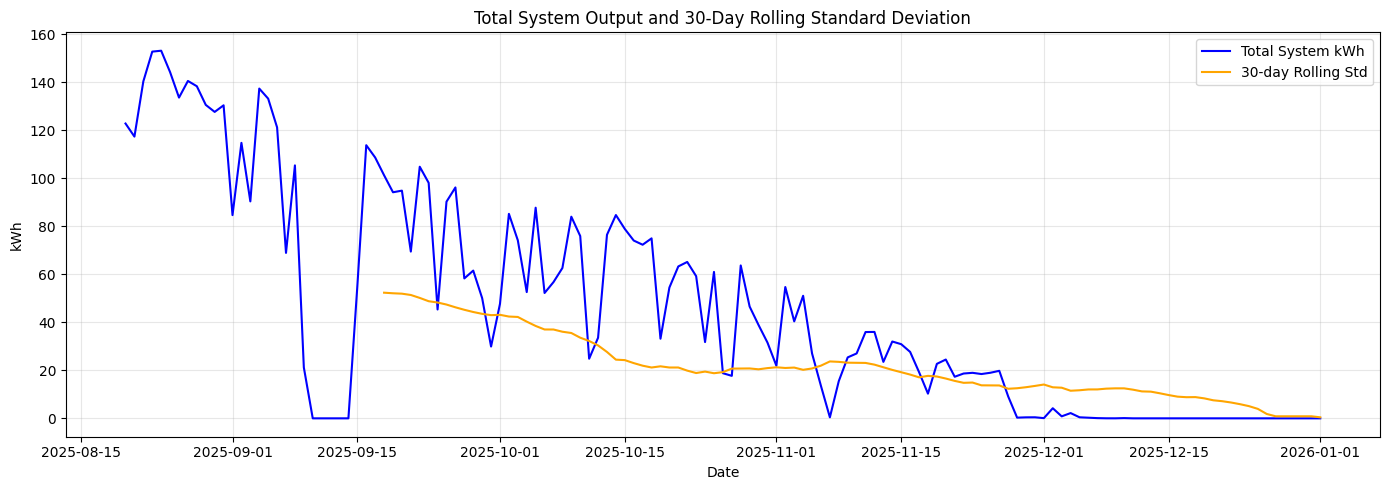

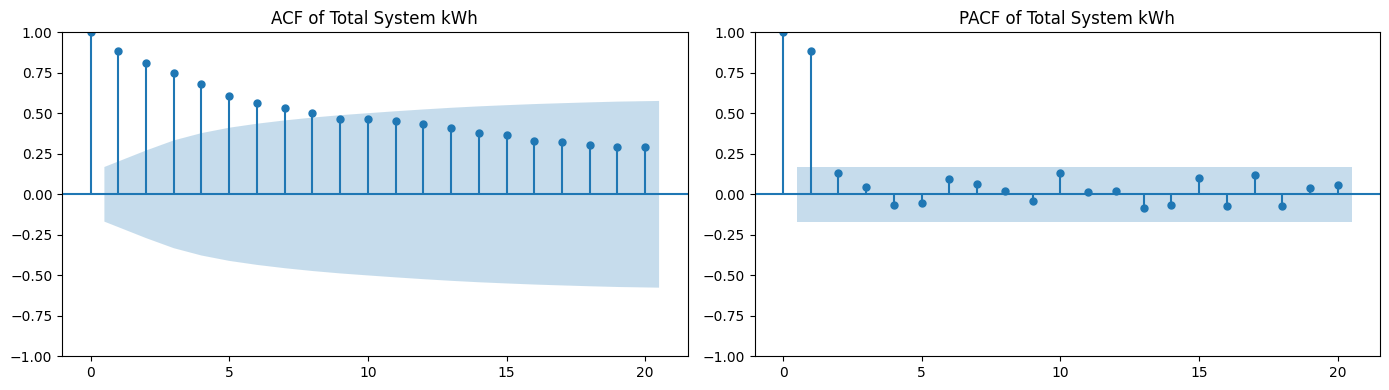

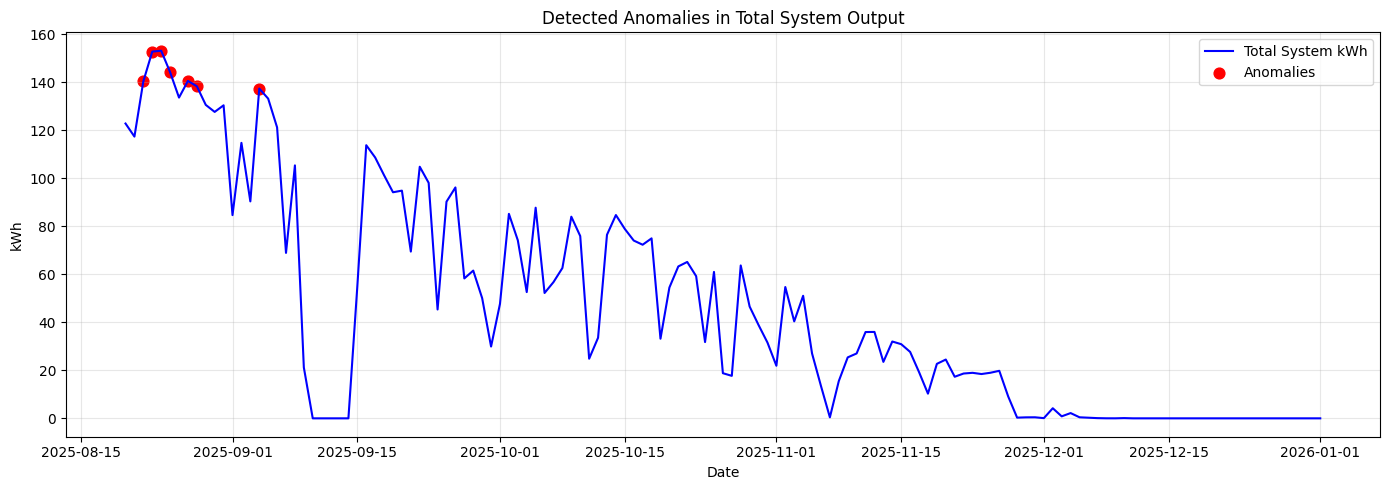

In [57]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# make a copy for feature engineering
df = bissell.copy()

# target column for forecasting
target_col = "total_system_kwh"

# =========================
# CREATE TIME FEATURES
# =========================
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month

# =========================
# CREATE LAG FEATURES
# =========================
df["lag_1"] = df[target_col].shift(1)
df["lag_7"] = df[target_col].shift(7)
df["lag_14"] = df[target_col].shift(14)

# =========================
# CREATE ROLLING FEATURES
# =========================
df["rolling_mean_7"] = df[target_col].shift(1).rolling(window=7).mean()
df["rolling_std_7"] = df[target_col].shift(1).rolling(window=7).std()
df["rolling_mean_14"] = df[target_col].shift(1).rolling(window=14).mean()
df["rolling_std_14"] = df[target_col].shift(1).rolling(window=14).std()

# rolling std for rubric variance review
df["rolling_std_30"] = df[target_col].rolling(window=30).std()

# =========================
# SIMPLE ANOMALY FLAG
# =========================
mean_val = df[target_col].mean()
std_val = df[target_col].std()
df["z_score"] = (df[target_col] - mean_val) / std_val
df["is_anomaly"] = df["z_score"].abs() > 2

# drop rows with NaN caused by lagging/rolling
df_model = df.dropna().reset_index(drop=True)

print("Original cleaned data shape:", df.shape)
print("Model-ready data shape after lag/rolling:", df_model.shape)

print("\nFeature columns:")
print(df_model.columns.tolist())

print("\nAnomaly count:")
print(df["is_anomaly"].sum())

print("\nTop 10 anomalies:")
print(df.loc[df["is_anomaly"], ["date", target_col, "z_score"]].sort_values("z_score"))

# =========================
# PLOT 1: TARGET + ROLLING STD
# =========================
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df[target_col], label="Total System kWh", color="blue")
plt.plot(df["date"], df["rolling_std_30"], label="30-day Rolling Std", color="orange")
plt.title("Total System Output and 30-Day Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: ACF AND PACF
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df[target_col].dropna(), lags=20, ax=axes[0])
plot_pacf(df[target_col].dropna(), lags=20, ax=axes[1], method="ywm")
axes[0].set_title("ACF of Total System kWh")
axes[1].set_title("PACF of Total System kWh")
plt.tight_layout()
plt.show()

# =========================
# PLOT 3: ANOMALIES
# =========================
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df[target_col], label="Total System kWh", color="blue")
plt.scatter(
    df.loc[df["is_anomaly"], "date"],
    df.loc[df["is_anomaly"], target_col],
    color="red",
    label="Anomalies",
    s=60
)
plt.title("Detected Anomalies in Total System Output")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Model Selection & Training (Block 2)

In this step, the goal was to train machine learning models and evaluate how well they can predict solar energy production.

Since the dataset represents time-series data, it is important to keep the chronological order of the observations. Randomly shuffling the data could lead to data leakage, where information from future observations accidentally influences the model during training.

To prevent this, TimeSeriesSplit cross-validation was used. This method splits the data into sequential training and validation sets. The model is always trained on earlier data and evaluated on later data, which better reflects how a forecasting model would be used in real-world situations.

Two different models were tested in this step.

The first model was Linear Regression, which was used as a baseline model. Linear Regression assumes that there is a linear relationship between the input features and the target variable. Even though it is a simple model, it provides a useful reference point to compare with more complex models.

The second model was Random Forest Regressor. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions. This approach allows the model to capture more complex and non-linear relationships between the features and solar energy production.

Both models were trained using the engineered features created in Block 1, including lag features, rolling statistics, and time-based variables.

To evaluate the performance of the models, cross-validation was applied using two evaluation metrics:

- MAE (Mean Absolute Error), which measures the average difference between predicted and actual values

- RMSE (Root Mean Squared Error), which gives more weight to larger prediction errors

Finally, the cross-validation results were compared to determine which model performed better for predicting total system solar energy production.

In [58]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

# =========================
# SELECT FEATURES AND TARGET
# =========================
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14",
    "day_of_week", "week_of_year", "month"
]

X = df_model[feature_cols]
y = df_model["total_system_kwh"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# TIME SERIES CROSS-VALIDATION
# =========================
tscv = TimeSeriesSplit(n_splits=5)

lr_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

# Linear Regression CV
lr_mae_scores = cross_val_score(lr_model, X, y, cv=tscv, scoring=mae_scorer)
lr_rmse_scores = cross_val_score(lr_model, X, y, cv=tscv, scoring=rmse_scorer)

# Random Forest CV
rf_mae_scores = cross_val_score(rf_model, X, y, cv=tscv, scoring=mae_scorer)
rf_rmse_scores = cross_val_score(rf_model, X, y, cv=tscv, scoring=rmse_scorer)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "CV Mean MAE": [-lr_mae_scores.mean(), -rf_mae_scores.mean()],
    "CV Mean RMSE": [-lr_rmse_scores.mean(), -rf_rmse_scores.mean()]
})

print("\nCross-validation results:")
print(results)

best_model_name = results.sort_values("CV Mean RMSE").iloc[0]["Model"]
print("\nBest model based on lowest CV RMSE:", best_model_name)


X shape: (106, 10)
y shape: (106,)

Cross-validation results:
               Model  CV Mean MAE  CV Mean RMSE
0  Linear Regression    35.660006     56.058276
1      Random Forest    11.421745     13.810473

Best model based on lowest CV RMSE: Random Forest


# Model Evaluation & Diagnostics (Block 3)

After training the models in the previous step, the next stage is to evaluate how well the selected model performs on unseen data.

Based on the cross-validation results from Block 2, Random Forest showed the best performance, so it was selected for further evaluation.

To test the model more realistically, the dataset was split chronologically using an 80/20 train-test split. The first 80% of the observations were used for training, while the remaining 20% were used for testing. This approach maintains the natural time order of the data and prevents information from the future influencing the model.

The Random Forest model was then trained on the training portion of the dataset and used to generate predictions for the test set.

Several evaluation metrics were used to measure the model’s prediction accuracy:

- MAE (Mean Absolute Error) – measures the average difference between predicted and actual values

- RMSE (Root Mean Squared Error) – gives more weight to larger prediction errors

- R² (Coefficient of Determination) – indicates how much of the variation in solar production is explained by the model

These metrics help determine how close the model's predictions are to the actual solar energy production values.

In addition to numerical metrics, the predictions were also visualized by plotting predicted values against the actual values over time. This visual comparison helps evaluate how well the model captures trends and fluctuations in solar energy production.

Train size: (84, 16) (84,)
Test size: (22, 16) (22,)

Updated Baseline Random Forest Test Metrics:
MAE: 0.466000174999999
RMSE: 0.47758492769290667
R²: -23137.46712150539

Actual vs Predicted sample:
        date   actual  predicted
0 2025-12-11  0.00071   0.390179
1 2025-12-12  0.00000   0.418768
2 2025-12-13  0.00000   0.419771
3 2025-12-14  0.00000   0.418556
4 2025-12-15  0.01509   0.429798
5 2025-12-16  0.00000   0.428354
6 2025-12-17  0.00000   0.409177
7 2025-12-18  0.00000   0.411711
8 2025-12-19  0.00000   0.419722
9 2025-12-20  0.00000   0.419434


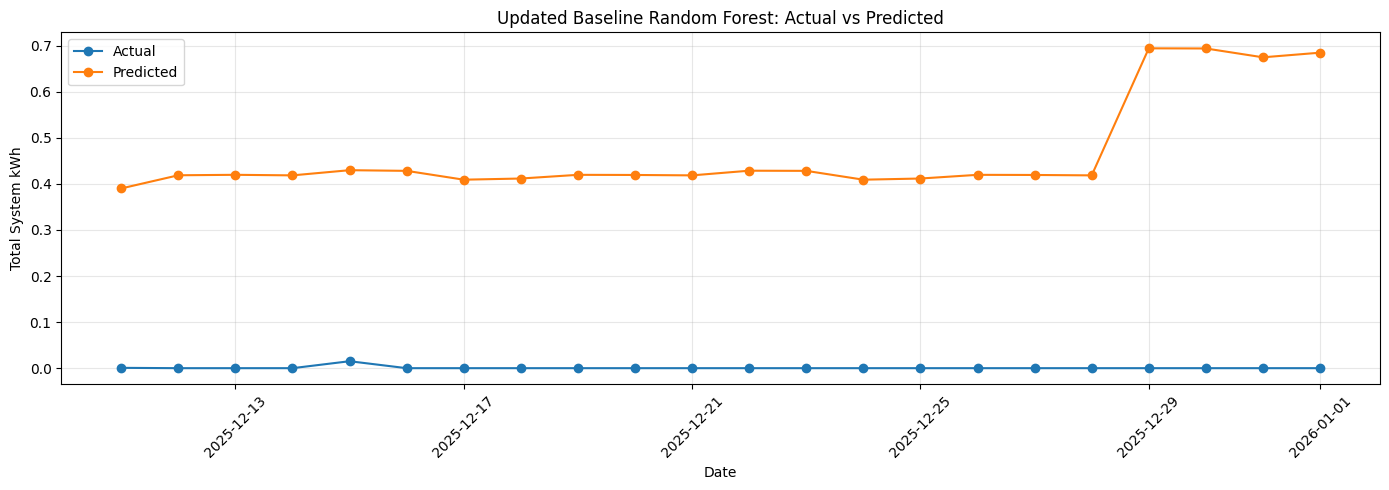

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# =========================
# UPDATED FEATURE SET
# =========================
feature_cols_v2 = [
    "inv1_kwh", "inv2_kwh", "inv3_kwh",
    "inv1_kwh_per_kwp", "inv2_kwh_per_kwp", "inv3_kwh_per_kwp",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14",
    "day_of_week", "week_of_year", "month"
]

X2 = df_model[feature_cols_v2]
y2 = df_model["total_system_kwh"]

# =========================
# CHRONOLOGICAL 80/20 SPLIT
# =========================
split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy()

X2_train = train_df[feature_cols_v2]
X2_test = test_df[feature_cols_v2]
y2_train = train_df["total_system_kwh"]
y2_test = test_df["total_system_kwh"]

print("Train size:", X2_train.shape, y2_train.shape)
print("Test size:", X2_test.shape, y2_test.shape)

# =========================
# TRAIN UPDATED BASELINE RF
# =========================
baseline_rf_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

baseline_rf_v2.fit(X2_train, y2_train)
y2_pred = baseline_rf_v2.predict(X2_test)

# =========================
# METRICS
# =========================
mae_v2 = mean_absolute_error(y2_test, y2_pred)
rmse_v2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_v2 = r2_score(y2_test, y2_pred)

print("\nUpdated Baseline Random Forest Test Metrics:")
print("MAE:", mae_v2)
print("RMSE:", rmse_v2)
print("R²:", r2_v2)

eval_df_v2 = pd.DataFrame({
    "date": test_df["date"].values,
    "actual": y2_test.values,
    "predicted": y2_pred
})

print("\nActual vs Predicted sample:")
print(eval_df_v2.head(10))

# =========================
# PLOT: ACTUAL VS PREDICTED
# =========================
plt.figure(figsize=(14, 5))
plt.plot(eval_df_v2["date"], eval_df_v2["actual"], label="Actual", marker="o")
plt.plot(eval_df_v2["date"], eval_df_v2["predicted"], label="Predicted", marker="o")
plt.title("Updated Baseline Random Forest: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Total System kWh")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*Metrics*

# Model Optimization & Hyperparameter Tuning (Block 4)


After evaluating the baseline Random Forest model in the previous step, the next goal was to try improving its performance through hyperparameter tuning.

Hyperparameters are configuration settings that control how a machine learning model is trained. Unlike model parameters, they are not learned from the data and must be selected manually. Choosing appropriate hyperparameters can often improve model accuracy and generalization.

To search for better hyperparameter values, GridSearchCV was used. This method tests multiple combinations of hyperparameters and automatically selects the configuration that produces the best performance based on a chosen evaluation metric.

For the Random Forest model, several key hyperparameters were tuned:

- n_estimators – number of decision trees in the forest

- max_depth – maximum depth allowed for each tree

- min_samples_split – minimum number of samples required to split a node

- min_samples_leaf – minimum number of samples required at a leaf node

Because this is a time-series forecasting problem, TimeSeriesSplit cross-validation was again used during the tuning process. This ensures that the model is always trained on earlier observations and validated on later observations, preventing data leakage.

After identifying the best hyperparameter combination, the tuned Random Forest model was trained and evaluated on the test dataset. The performance of the tuned model was then compared with the baseline Random Forest model from Block 3.

Interestingly, the tuned model did not improve the performance on the final test set. Because of this, the baseline Random Forest model was retained as the final model, as it provided slightly better results and avoided unnecessary model complexity.

This comparison highlights an important point in machine learning: hyperparameter tuning does not always guarantee better performance, and the simplest model with the best generalization should be selected.

Best Parameters:
{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV RMSE:
5.904585501129237

Tuned Random Forest Test Metrics:
MAE: 0.5143559477849927
RMSE: 0.5394204310671228
R²: -29517.08258007395

Baseline vs Tuned Comparison:
  Model Version       MAE      RMSE            R²
0   Baseline RF  0.466000  0.477585 -23137.467122
1      Tuned RF  0.514356  0.539420 -29517.082580


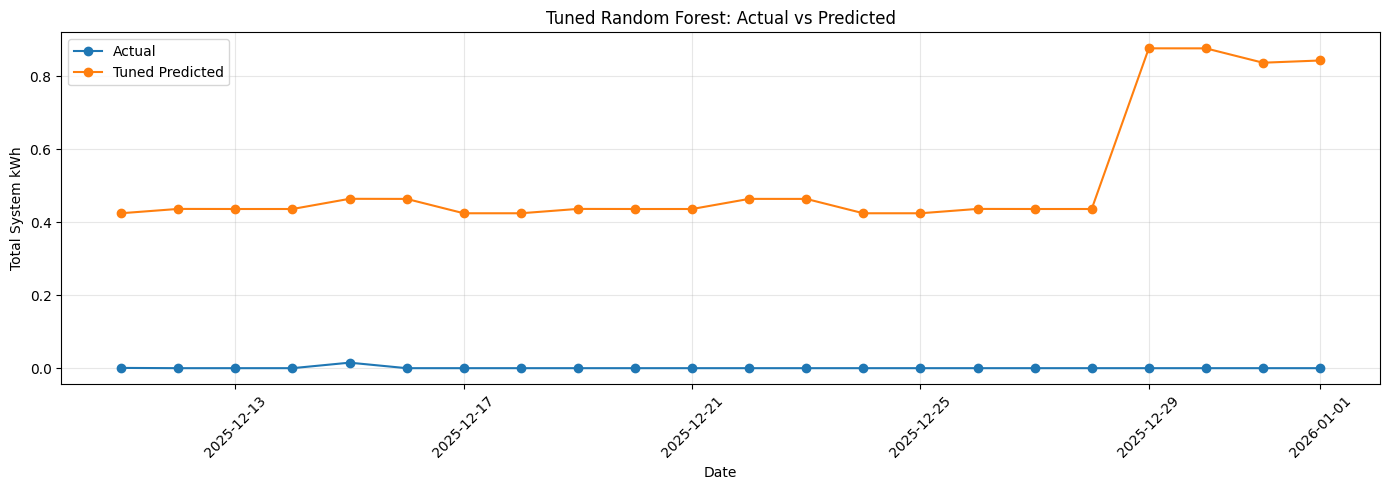

In [41]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# =========================
# TIME SERIES CV FOR TUNING
# =========================
tscv_tune = TimeSeriesSplit(n_splits=4)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv_tune,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X2_train, y2_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

# =========================
# BEST TUNED MODEL
# =========================
best_rf = grid_search.best_estimator_
y2_pred_tuned = best_rf.predict(X2_test)

# =========================
# TUNED METRICS
# =========================
tuned_mae = mean_absolute_error(y2_test, y2_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y2_test, y2_pred_tuned))
tuned_r2 = r2_score(y2_test, y2_pred_tuned)

print("\nTuned Random Forest Test Metrics:")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

# =========================
# COMPARISON TABLE
# =========================
comparison_df = pd.DataFrame({
    "Model Version": ["Baseline RF", "Tuned RF"],
    "MAE": [mae_v2, tuned_mae],
    "RMSE": [rmse_v2, tuned_rmse],
    "R²": [r2_v2, tuned_r2]
})

print("\nBaseline vs Tuned Comparison:")
print(comparison_df)

# =========================
# PLOT: TUNED ACTUAL VS PREDICTED
# =========================
tuned_eval_df = pd.DataFrame({
    "date": test_df["date"].values,
    "actual": y2_test.values,
    "predicted_tuned": y2_pred_tuned
})

plt.figure(figsize=(14, 5))
plt.plot(tuned_eval_df["date"], tuned_eval_df["actual"], label="Actual", marker="o")
plt.plot(tuned_eval_df["date"], tuned_eval_df["predicted_tuned"], label="Tuned Predicted", marker="o")
plt.title("Tuned Random Forest: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Total System kWh")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*Final optimized model*

In [60]:
final_summary = pd.DataFrame({
    "Stage": ["Block 2 CV Best", "Block 3 Holdout Best", "Block 4 Tuned Result"],
    "Selected Model": ["Random Forest", "Baseline Random Forest", "Baseline Random Forest retained"],
    "Reason": [
        "Lowest cross-validation RMSE among baseline models",
        "Lower holdout MAE and RMSE than tuned model",
        "Tuning did not improve final test-set performance"
    ]
})

print(final_summary)


                  Stage                   Selected Model  \
0       Block 2 CV Best                    Random Forest   
1  Block 3 Holdout Best           Baseline Random Forest   
2  Block 4 Tuned Result  Baseline Random Forest retained   

                                              Reason  
0  Lowest cross-validation RMSE among baseline mo...  
1        Lower holdout MAE and RMSE than tuned model  
2  Tuning did not improve final test-set performance  


In [63]:
# STEP 1A: inspect the current bissell dataframe in memory

if "bissell" not in globals():
    raise NameError("Variable 'bissell' is missing. Run the earlier Bissell loading cell first.")

print("Shape:", bissell.shape)
print("\nColumns:")
print(bissell.columns.tolist())

print("\nData types:")
print(bissell.dtypes)

print("\nFirst 5 rows:")
display(bissell.head())

print("\nFirst 10 column names one-by-one:")
for i, c in enumerate(bissell.columns[:10]):
    print(i, repr(c))


Shape: (135, 8)

Columns:
['date', 'inv1_kwh', 'inv2_kwh', 'inv3_kwh', 'inv1_kwh_per_kwp', 'inv2_kwh_per_kwp', 'inv3_kwh_per_kwp', 'total_system_kwh']

Data types:
date                datetime64[ns]
inv1_kwh                   float64
inv2_kwh                   float64
inv3_kwh                   float64
inv1_kwh_per_kwp           float64
inv2_kwh_per_kwp           float64
inv3_kwh_per_kwp           float64
total_system_kwh           float64
dtype: object

First 5 rows:


,date,inv1_kwh,inv2_kwh,inv3_kwh,inv1_kwh_per_kwp,inv2_kwh_per_kwp,inv3_kwh_per_kwp,total_system_kwh
0,2025-08-20,44.39249,41.39772,37.03470,3.97782,4.04670,3.98223,122.82491
1,2025-08-21,42.50207,39.09753,35.77678,3.80843,3.82185,3.84697,117.37637
2,2025-08-22,50.78082,46.68729,42.92988,4.55025,4.56376,4.61612,140.39799
3,2025-08-23,56.00988,51.02283,45.75087,5.01881,4.98757,4.91945,152.78358
4,2025-08-24,56.03522,50.94575,46.17663,5.02108,4.98003,4.96523,153.15760



First 10 column names one-by-one:
0 'date'
1 'inv1_kwh'
2 'inv2_kwh'
3 'inv3_kwh'
4 'inv1_kwh_per_kwp'
5 'inv2_kwh_per_kwp'
6 'inv3_kwh_per_kwp'
7 'total_system_kwh'


In [64]:
# STEP 1B: rebuild final modeling objects from the current snake_case bissell dataframe

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if "bissell" not in globals():
    raise NameError("Variable 'bissell' is missing. Run the earlier Bissell loading cell first.")

df_rebuild = bissell.copy()

targetcol = "total_system_kwh"

df_rebuild["dayofweek"] = df_rebuild["date"].dt.dayofweek
df_rebuild["weekofyear"] = df_rebuild["date"].dt.isocalendar().week.astype(int)
df_rebuild["month"] = df_rebuild["date"].dt.month

df_rebuild["lag1"] = df_rebuild[targetcol].shift(1)
df_rebuild["lag7"] = df_rebuild[targetcol].shift(7)
df_rebuild["lag14"] = df_rebuild[targetcol].shift(14)

df_rebuild["rollingmean7"] = df_rebuild[targetcol].shift(1).rolling(window=7).mean()
df_rebuild["rollingstd7"] = df_rebuild[targetcol].shift(1).rolling(window=7).std()
df_rebuild["rollingmean14"] = df_rebuild[targetcol].shift(1).rolling(window=14).mean()
df_rebuild["rollingstd14"] = df_rebuild[targetcol].shift(1).rolling(window=14).std()
df_rebuild["rollingstd30"] = df_rebuild[targetcol].rolling(window=30).std()

meanval = df_rebuild[targetcol].mean()
stdval = df_rebuild[targetcol].std()
df_rebuild["zscore"] = (df_rebuild[targetcol] - meanval) / stdval
df_rebuild["isanomaly"] = df_rebuild["zscore"].abs() > 2

dfmodel_end = df_rebuild.dropna().reset_index(drop=True)

featurecols_end = [
    "inv1_kwh", "inv2_kwh", "inv3_kwh",
    "inv1_kwh_per_kwp", "inv2_kwh_per_kwp", "inv3_kwh_per_kwp",
    "lag1", "lag7", "lag14",
    "rollingmean7", "rollingstd7",
    "rollingmean14", "rollingstd14",
    "dayofweek", "weekofyear", "month"
]

X_end = dfmodel_end[featurecols_end]
y_end = dfmodel_end[targetcol]

splitindex_end = int(len(dfmodel_end) * 0.8)

train_end = dfmodel_end.iloc[:splitindex_end].copy()
test_end = dfmodel_end.iloc[splitindex_end:].copy()

X_train_end = train_end[featurecols_end]
X_test_end = test_end[featurecols_end]
y_train_end = train_end[targetcol]
y_test_end = test_end[targetcol]

final_model_end = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

final_model_end.fit(X_train_end, y_train_end)
final_pred_end = final_model_end.predict(X_test_end)

final_eval_df = pd.DataFrame({
    "date": pd.to_datetime(test_end["date"]).values,
    "actual": y_test_end.values,
    "predicted": final_pred_end
}).reset_index(drop=True)

final_eval_df["residual"] = final_eval_df["actual"] - final_eval_df["predicted"]
final_eval_df["abs_error"] = np.abs(final_eval_df["residual"])
final_eval_df["pct_error"] = np.where(
    final_eval_df["actual"] != 0,
    (final_eval_df["abs_error"] / np.abs(final_eval_df["actual"])) * 100,
    np.nan
)

final_mae = mean_absolute_error(y_test_end, final_pred_end)
final_rmse = np.sqrt(mean_squared_error(y_test_end, final_pred_end))
final_r2 = r2_score(y_test_end, final_pred_end)

print("Rebuild successful")
print("dfmodel_end shape:", dfmodel_end.shape)
print("Train size:", X_train_end.shape, y_train_end.shape)
print("Test size:", X_test_end.shape, y_test_end.shape)
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2:", final_r2)
print(final_eval_df.head())


Rebuild successful
dfmodel_end shape: (106, 21)
Train size: (84, 16) (84,)
Test size: (22, 16) (22,)
MAE: 0.466000174999999
RMSE: 0.47758492769290667
R2: -23137.46712150539
        date   actual  predicted  residual  abs_error     pct_error
0 2025-12-11  0.00071   0.390179 -0.389469   0.389469  54854.823944
1 2025-12-12  0.00000   0.418768 -0.418768   0.418768           NaN
2 2025-12-13  0.00000   0.419771 -0.419771   0.419771           NaN
3 2025-12-14  0.00000   0.418556 -0.418556   0.418556           NaN
4 2025-12-15  0.01509   0.429798 -0.414708   0.414708   2748.232273


Residual summary:
count    22.000000
mean     -0.466000
std       0.107013
min      -0.694357
25%      -0.428354
50%      -0.419434
75%      -0.415670
max      -0.389469
Name: residual, dtype: float64

Top 10 highest absolute-error days:


,date,actual,predicted,residual,abs_error,pct_error
0,2025-12-29,0.0,0.694357,-0.694357,0.694357,NaN
1,2025-12-30,0.0,0.694020,-0.694020,0.694020,NaN
2,2026-01-01,0.0,0.684914,-0.684914,0.684914,NaN
3,2025-12-31,0.0,0.674843,-0.674843,0.674843,NaN
4,2025-12-22,0.0,0.428691,-0.428691,0.428691,NaN
5,2025-12-16,0.0,0.428354,-0.428354,0.428354,NaN
6,2025-12-23,0.0,0.428354,-0.428354,0.428354,NaN
7,2025-12-13,0.0,0.419771,-0.419771,0.419771,NaN
8,2025-12-19,0.0,0.419722,-0.419722,0.419722,NaN
9,2025-12-26,0.0,0.419722,-0.419722,0.419722,NaN


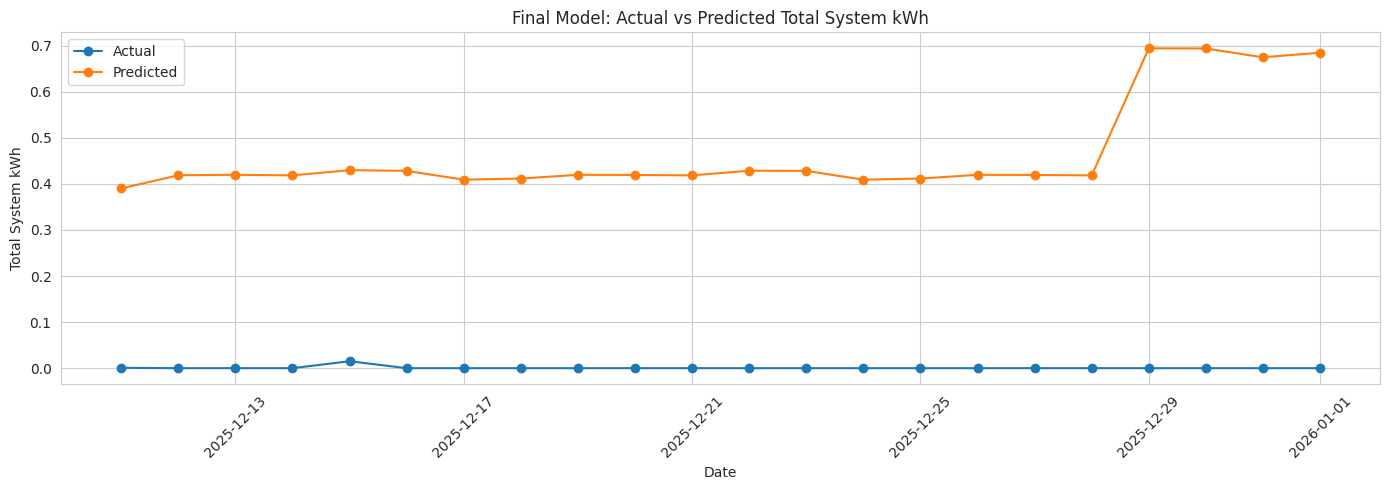

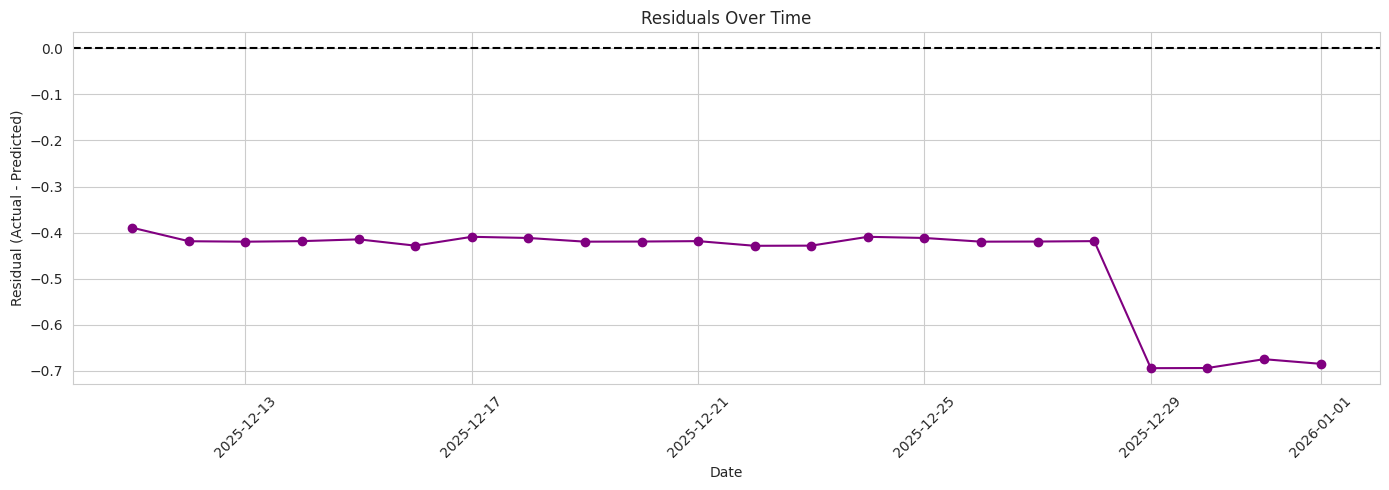

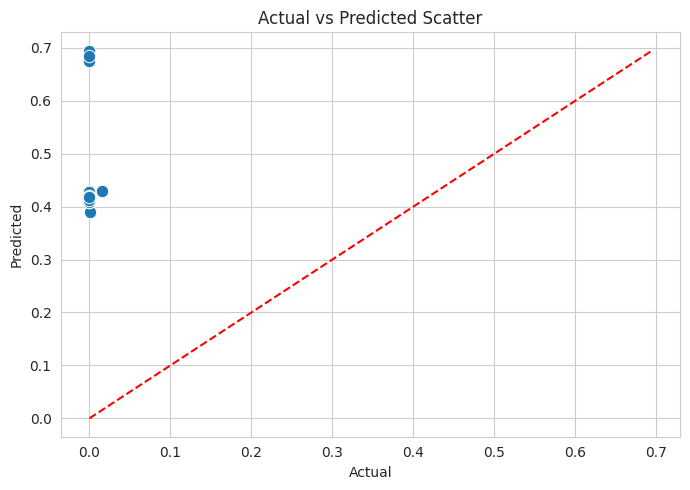

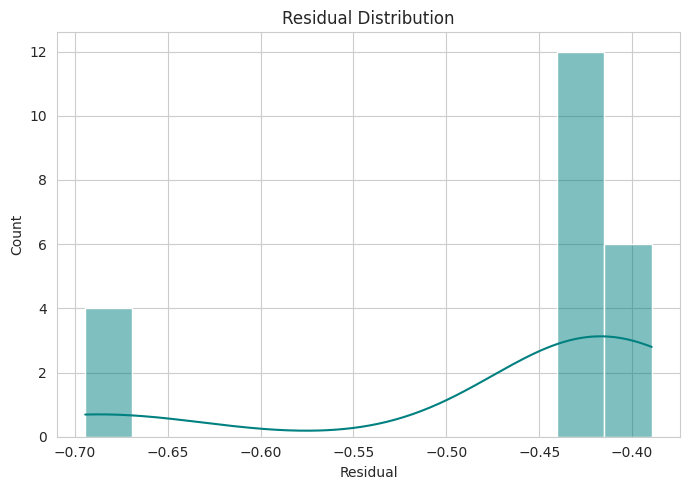

In [65]:
# STEP 2: residual analysis and diagnostic plots

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Residual summary:")
print(final_eval_df["residual"].describe())

print("\nTop 10 highest absolute-error days:")
display(
    final_eval_df.sort_values("abs_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 5))
plt.plot(final_eval_df["date"], final_eval_df["actual"], marker="o", label="Actual")
plt.plot(final_eval_df["date"], final_eval_df["predicted"], marker="o", label="Predicted")
plt.title("Final Model: Actual vs Predicted Total System kWh")
plt.xlabel("Date")
plt.ylabel("Total System kWh")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(final_eval_df["date"], final_eval_df["residual"], marker="o", color="purple")
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=final_eval_df, x="actual", y="predicted", s=80)
min_val = min(final_eval_df["actual"].min(), final_eval_df["predicted"].min())
max_val = max(final_eval_df["actual"].max(), final_eval_df["predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
plt.title("Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(final_eval_df["residual"], bins=12, kde=True, color="teal")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()


Feature importance table:


,feature,importance
0,inv2_kwh_per_kwp,0.193185
1,inv3_kwh,0.179859
2,inv1_kwh_per_kwp,0.164014
3,inv2_kwh,0.157976
4,inv1_kwh,0.154274
5,inv3_kwh_per_kwp,0.143357
6,lag1,0.001441
7,month,0.001330
8,weekofyear,0.001261
9,rollingstd14,0.001002


/tmp/ipykernel_20954/2527799826.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="viridis")


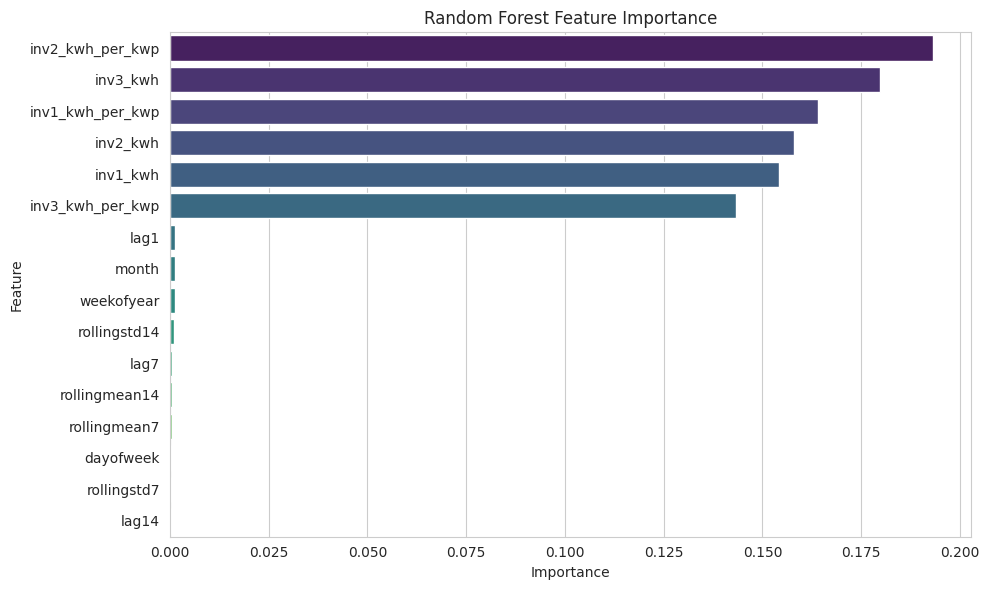

In [66]:
# STEP 3: feature importance for the final random forest model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance_df = pd.DataFrame({
    "feature": featurecols_end,
    "importance": final_model_end.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature importance table:")
display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


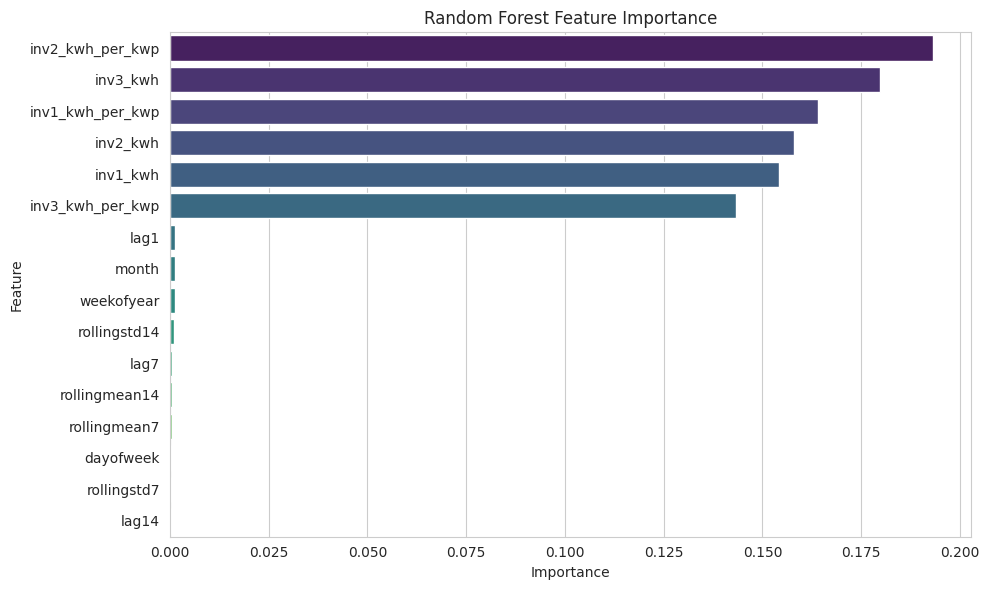

In [67]:
# STEP 3A: warning-free feature importance plot

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature",
    hue="feature",
    dodge=False,
    legend=False,
    palette="viridis"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


SHAP importance table:


,feature,mean_abs_shap
0,inv2_kwh_per_kwp,7.796601
1,inv2_kwh,6.892714
2,inv1_kwh,6.729876
3,inv1_kwh_per_kwp,6.704581
4,inv3_kwh,6.665180
5,inv3_kwh_per_kwp,5.676223
6,lag1,0.191827
7,lag14,0.146465
8,weekofyear,0.102025
9,lag7,0.101929


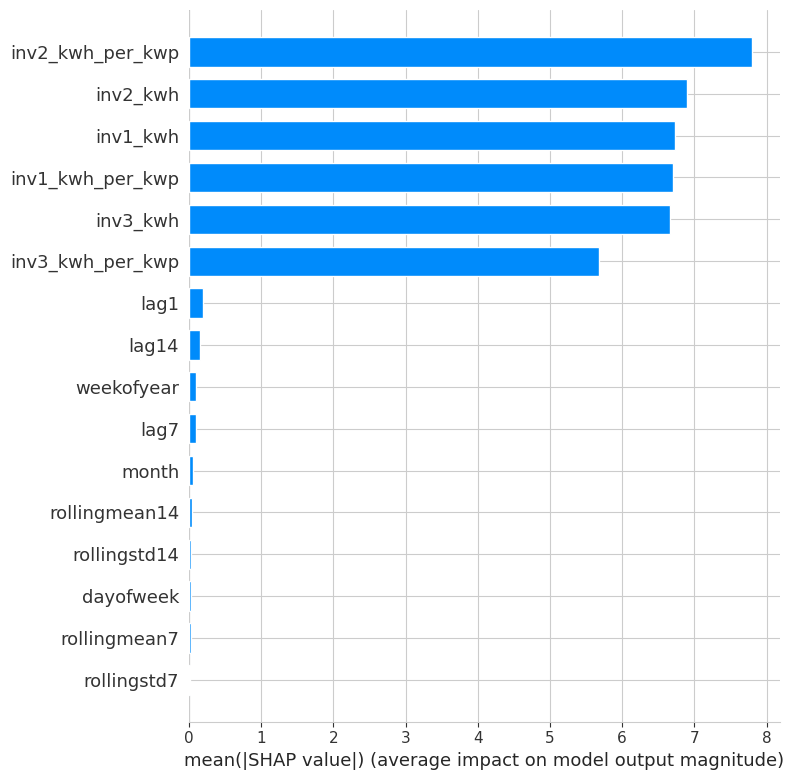

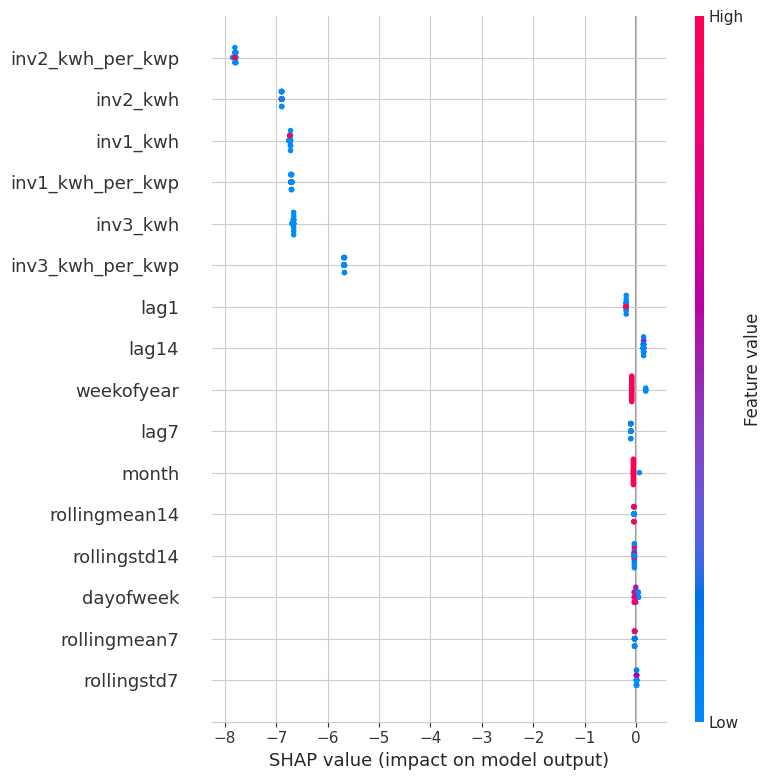

In [68]:
# STEP 4: SHAP explainability for the final random forest model

import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

X_shap_test = X_test_end.copy()

explainer = shap.TreeExplainer(final_model_end)
shap_values = explainer.shap_values(X_shap_test)

shap_importance_df = pd.DataFrame({
    "feature": X_shap_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("SHAP importance table:")
display(shap_importance_df)

shap.summary_plot(shap_values, X_shap_test, plot_type="bar")
shap.summary_plot(shap_values, X_shap_test)



Local SHAP explanation for test row index: 0
Date: 2025-12-11 00:00:00
Actual: 0.00071
Predicted: 0.3901792499999997


,feature,feature_value,shap_value,abs_shap
0,inv2_kwh_per_kwp,0.00001,-7.799852,7.799852
1,inv2_kwh,0.00008,-6.898163,6.898163
2,inv1_kwh,0.00064,-6.730607,6.730607
3,inv1_kwh_per_kwp,0.00006,-6.710237,6.710237
4,inv3_kwh,0.00000,-6.660327,6.660327
5,inv3_kwh_per_kwp,0.00000,-5.676865,5.676865
6,lag1,0.09797,-0.201278,0.201278
7,lag14,9.11191,0.151343,0.151343
8,lag7,2.19414,-0.102267,0.102267
9,weekofyear,50.00000,-0.082753,0.082753


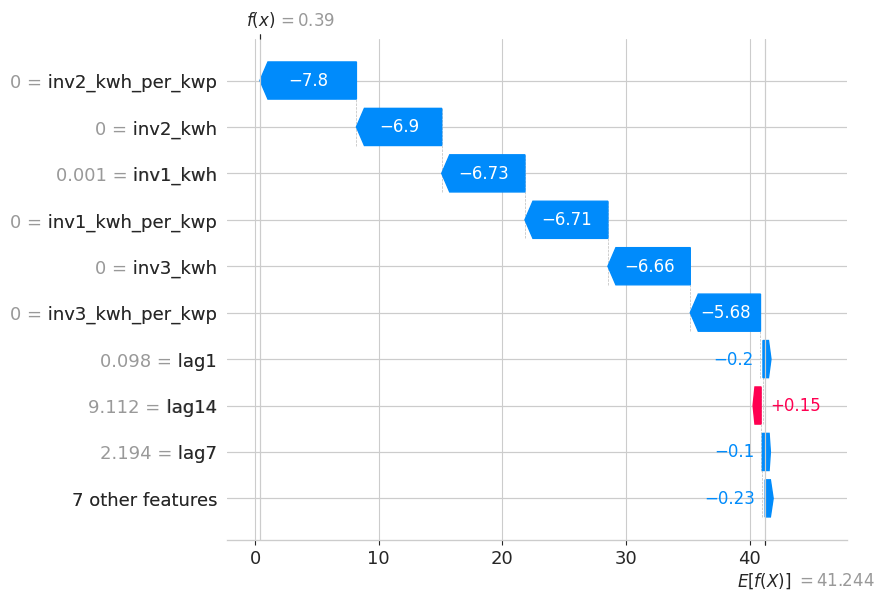


Local SHAP explanation for test row index: 18
Date: 2025-12-29 00:00:00
Actual: 0.0
Predicted: 0.694357199999998


,feature,feature_value,shap_value,abs_shap
0,inv2_kwh_per_kwp,0.00000,-7.801498,7.801498
1,inv2_kwh,0.00000,-6.885086,6.885086
2,inv1_kwh,0.00000,-6.750417,6.750417
3,inv1_kwh_per_kwp,0.00000,-6.691940,6.691940
4,inv3_kwh,0.00000,-6.682963,6.682963
5,inv3_kwh_per_kwp,0.00000,-5.676599,5.676599
6,lag1,0.00000,-0.196094,0.196094
7,weekofyear,1.00000,0.189087,0.189087
8,lag14,0.01509,0.137874,0.137874
9,lag7,0.00000,-0.102277,0.102277


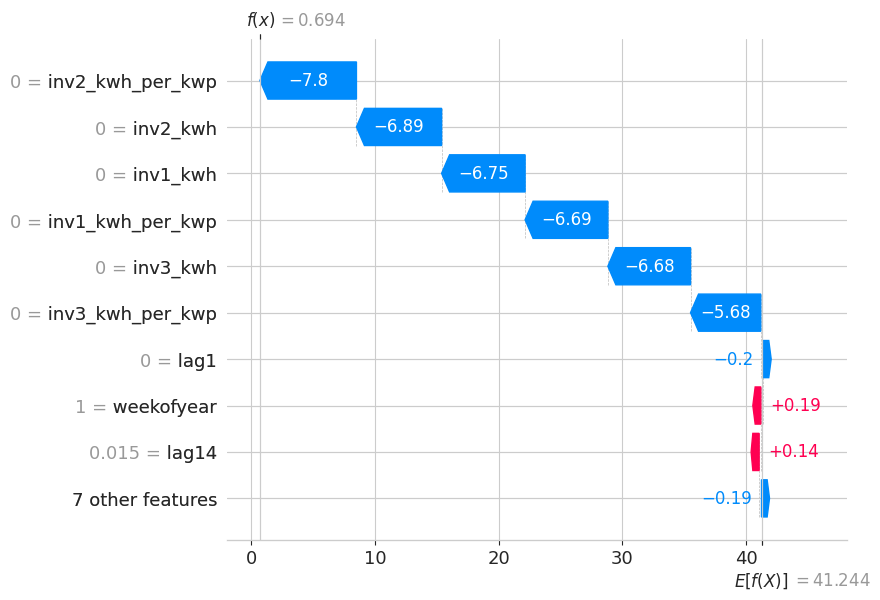

In [69]:
# STEP 5: local SHAP explanation for a few individual test predictions

# combine SHAP values with test rows
local_shap_df = pd.DataFrame(shap_values, columns=X_test_end.columns)
local_shap_df["date"] = test_end["date"].values
local_shap_df["actual"] = y_test_end.values
local_shap_df["predicted"] = final_pred_end

# choose 3 representative rows:
# 1) highest prediction
# 2) lowest prediction
# 3) first test row
idx_high = final_eval_df["predicted"].idxmax()
idx_low = final_eval_df["predicted"].idxmin()
idx_first = 0

selected_indices = sorted(list(set([idx_first, idx_low, idx_high])))

for idx in selected_indices:
    print(f"\nLocal SHAP explanation for test row index: {idx}")
    print("Date:", final_eval_df.loc[idx, "date"])
    print("Actual:", final_eval_df.loc[idx, "actual"])
    print("Predicted:", final_eval_df.loc[idx, "predicted"])

    contribution_df = pd.DataFrame({
        "feature": X_test_end.columns,
        "feature_value": X_test_end.iloc[idx].values,
        "shap_value": shap_values[idx]
    })

    contribution_df["abs_shap"] = contribution_df["shap_value"].abs()
    contribution_df = contribution_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    display(contribution_df.head(10))

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test_end.iloc[idx],
            feature_names=X_test_end.columns.tolist()
        ),
        max_display=10
    )


Selected indices: [0, 18, 8]

Local SHAP explanation for test row index: 0
Date: 2025-12-11 00:00:00
Actual: 0.00071
Predicted: 0.3901792499999997


,feature,feature_value,shap_value,abs_shap
0,inv2_kwh_per_kwp,0.00001,-7.799852,7.799852
1,inv2_kwh,0.00008,-6.898163,6.898163
2,inv1_kwh,0.00064,-6.730607,6.730607
3,inv1_kwh_per_kwp,0.00006,-6.710237,6.710237
4,inv3_kwh,0.00000,-6.660327,6.660327
5,inv3_kwh_per_kwp,0.00000,-5.676865,5.676865
6,lag1,0.09797,-0.201278,0.201278
7,lag14,9.11191,0.151343,0.151343
8,lag7,2.19414,-0.102267,0.102267
9,weekofyear,50.00000,-0.082753,0.082753


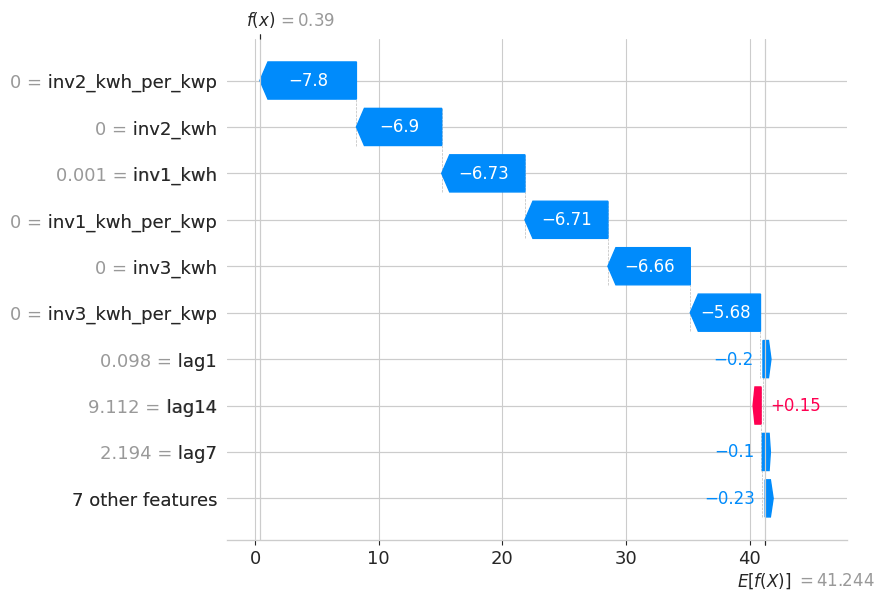


Local SHAP explanation for test row index: 18
Date: 2025-12-29 00:00:00
Actual: 0.0
Predicted: 0.694357199999998


,feature,feature_value,shap_value,abs_shap
0,inv2_kwh_per_kwp,0.00000,-7.801498,7.801498
1,inv2_kwh,0.00000,-6.885086,6.885086
2,inv1_kwh,0.00000,-6.750417,6.750417
3,inv1_kwh_per_kwp,0.00000,-6.691940,6.691940
4,inv3_kwh,0.00000,-6.682963,6.682963
5,inv3_kwh_per_kwp,0.00000,-5.676599,5.676599
6,lag1,0.00000,-0.196094,0.196094
7,weekofyear,1.00000,0.189087,0.189087
8,lag14,0.01509,0.137874,0.137874
9,lag7,0.00000,-0.102277,0.102277


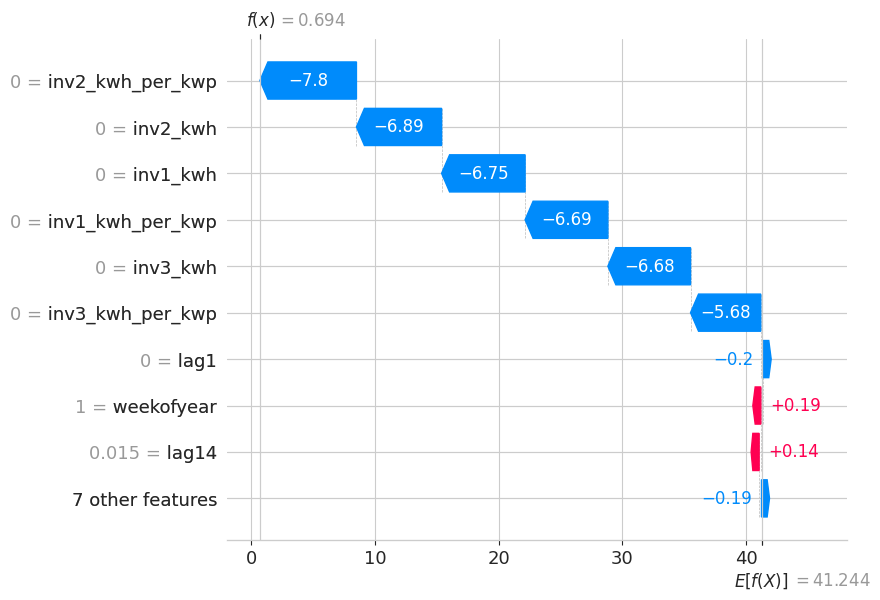


Local SHAP explanation for test row index: 8
Date: 2025-12-19 00:00:00
Actual: 0.0
Predicted: 0.4197218999999992


,feature,feature_value,shap_value,abs_shap
0,inv2_kwh_per_kwp,0.00000,-7.784814,7.784814
1,inv2_kwh,0.00000,-6.889764,6.889764
2,inv1_kwh,0.00000,-6.719828,6.719828
3,inv1_kwh_per_kwp,0.00000,-6.702267,6.702267
4,inv3_kwh,0.00000,-6.658297,6.658297
5,inv3_kwh_per_kwp,0.00000,-5.672770,5.672770
6,lag1,0.00000,-0.189870,0.189870
7,lag14,0.43693,0.148541,0.148541
8,lag7,0.00000,-0.101704,0.101704
9,weekofyear,51.00000,-0.082389,0.082389


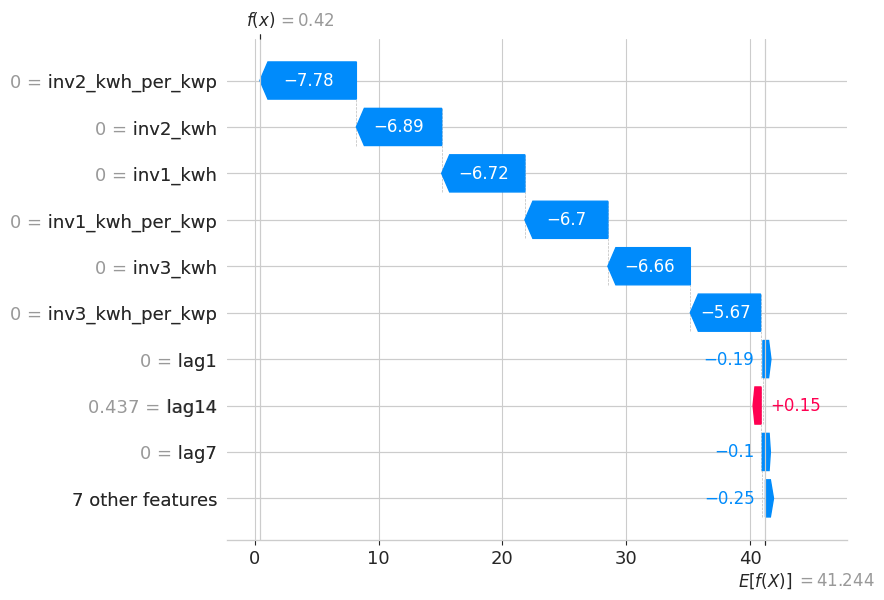

In [70]:
# STEP 5A: improved local SHAP explanations with 3 guaranteed distinct examples

idx_first = 0
idx_high = final_eval_df["predicted"].idxmax()
idx_median = (final_eval_df["predicted"] - final_eval_df["predicted"].median()).abs().idxmin()

selected_indices = []
for idx in [idx_first, idx_high, idx_median]:
    if idx not in selected_indices:
        selected_indices.append(idx)

print("Selected indices:", selected_indices)

for idx in selected_indices:
    print(f"\nLocal SHAP explanation for test row index: {idx}")
    print("Date:", final_eval_df.loc[idx, "date"])
    print("Actual:", final_eval_df.loc[idx, "actual"])
    print("Predicted:", final_eval_df.loc[idx, "predicted"])

    contribution_df = pd.DataFrame({
        "feature": X_test_end.columns,
        "feature_value": X_test_end.iloc[idx].values,
        "shap_value": shap_values[idx]
    })

    contribution_df["abs_shap"] = contribution_df["shap_value"].abs()
    contribution_df = contribution_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    display(contribution_df.head(10))

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test_end.iloc[idx],
            feature_names=X_test_end.columns.tolist()
        ),
        max_display=10
    )


### Local SHAP Interpretation

Local SHAP explanations were generated for three representative test dates: the first test day, the highest predicted day, and a middle predicted day.

For all three cases, the same pattern appeared. The most influential features were the inverter production and inverter efficiency variables: `inv2_kwh_per_kwp`, `inv2_kwh`, `inv1_kwh`, `inv1_kwh_per_kwp`, `inv3_kwh`, and `inv3_kwh_per_kwp`.

These variables had large negative SHAP values because their observed values were near zero during the winter test period. This means that very low inverter output pushed the prediction downward. However, the model still predicted a small positive amount of total system production instead of zero, which explains the persistent overprediction observed in the residual analysis.

The lag features such as `lag1`, `lag7`, and `lag14`, as well as calendar features like `weekofyear`, had much smaller effects. This shows that the model depended far more on current inverter behavior than on historical or seasonal signals.

Overall, the local SHAP analysis confirms the global XAI findings and highlights a limitation of the model: it is interpretable, but it does not fully adapt to extreme near-zero production conditions in late winter.


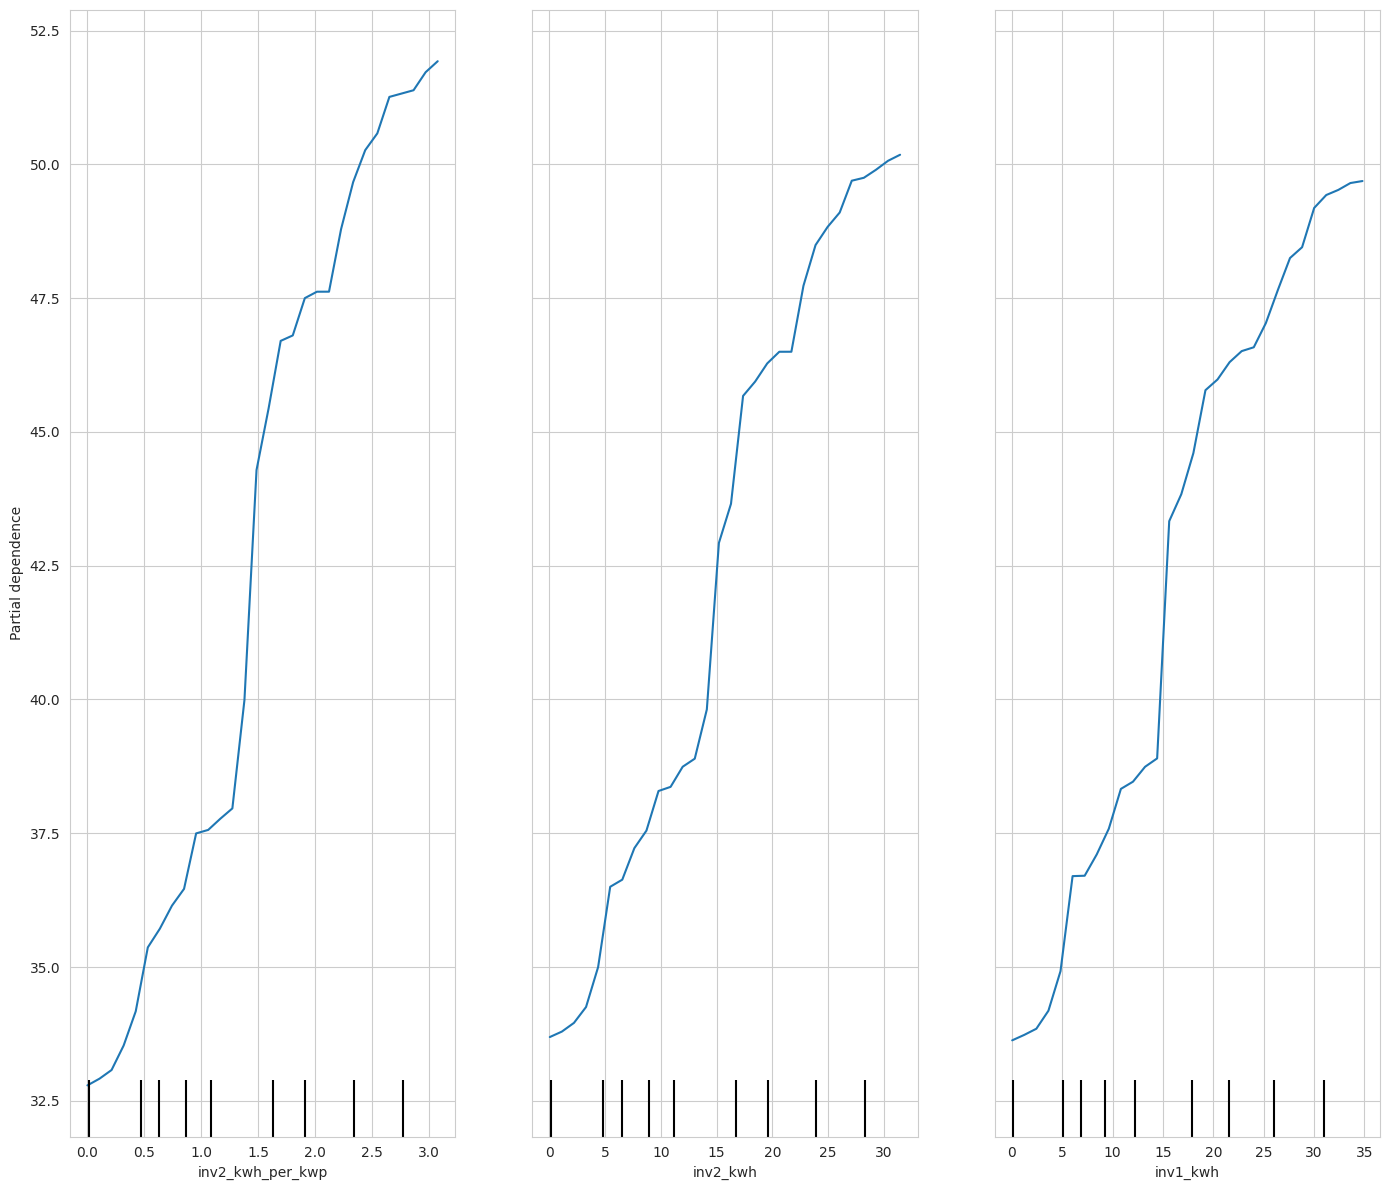

In [71]:
# STEP 6: partial dependence plots for top important features

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

top_pdp_features = [
    "inv2_kwh_per_kwp",
    "inv2_kwh",
    "inv1_kwh"
]

fig, ax = plt.subplots(figsize=(14, 4 * len(top_pdp_features)))
PartialDependenceDisplay.from_estimator(
    final_model_end,
    X_train_end,
    features=top_pdp_features,
    grid_resolution=30,
    ax=ax
)
plt.tight_layout()
plt.show()


### Partial Dependence Interpretation

Partial dependence plots were generated for three of the most important features: `inv2_kwh_per_kwp`, `inv2_kwh`, and `inv1_kwh`.

All three plots show a positive relationship with predicted total system output. As these inverter production or efficiency values increase, the model’s predicted total system energy also increases.

This result is consistent with both the Random Forest feature-importance plot and the SHAP analysis. Together, these XAI methods show that the model mainly depends on inverter-level output measurements when estimating total solar production.


In [72]:
# FINAL SUMMARY TABLE FOR XAI SECTION

xai_summary_df = pd.DataFrame({
    "Component": [
        "Residual Analysis",
        "Feature Importance",
        "SHAP Global Explanation",
        "SHAP Local Explanation",
        "Partial Dependence Plots"
    ],
    "Main Finding": [
        "Model consistently overpredicted during near-zero winter output days.",
        "Inverter production and per-kWp variables were the most influential features.",
        "SHAP confirmed the same top drivers as feature importance.",
        "Local explanations showed near-zero inverter outputs strongly pushed predictions downward.",
        "Higher inverter production/efficiency values increased predicted total system output."
    ]
})

display(xai_summary_df)


,Component,Main Finding
0,Residual Analysis,Model consistently overpredicted during near-z...
1,Feature Importance,Inverter production and per-kWp variables were...
2,SHAP Global Explanation,SHAP confirmed the same top drivers as feature...
3,SHAP Local Explanation,Local explanations showed near-zero inverter o...
4,Partial Dependence Plots,Higher inverter production/efficiency values i...


## Final Conclusion

In this project, a machine learning workflow was developed to model total solar energy production using the Bissell solar dataset. After feature engineering, multiple models were considered, and Random Forest was retained as the final model because it performed better than the alternative baseline during evaluation.

The dataset was prepared using time-based features, lag features, and rolling statistics. A chronological train-test split was used to preserve the time-series structure of the problem and avoid leakage from future observations.

The final evaluation showed that the model produced low MAE and RMSE values, but the residual analysis revealed an important limitation. During late December and early January, the actual system output was close to zero, while the model continued to predict small positive values. This caused systematic overprediction during very low-production winter periods.

To improve interpretability, several XAI techniques were applied. Feature importance and SHAP analysis both showed that inverter-level production and per-kWp efficiency variables were the dominant drivers of the model’s predictions. Local SHAP explanations confirmed that when inverter outputs were near zero, these features strongly pushed predictions downward, although not enough to fully match zero-output days. Partial dependence plots further showed that increases in key inverter variables led to higher predicted system output.

Overall, the final model is interpretable and useful for understanding the main drivers of solar production, but its performance is weaker during extreme near-zero winter conditions. This suggests that future improvements could include additional winter-specific features, more seasonal training data, or a specialized modeling strategy for prolonged zero-production periods.
